In [21]:
from pathlib import Path
import numpy as np
import pandas as pd

# ============================================================
# MAIN CONFIG
# ============================================================
DATASET_NAME = "new"
LABEL_NAME = "box2deg"

CASE_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output_softtest\exactlead_box2deg_case_tables_new_2009_2025_UPDATED"
)

OUT_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = OUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CM_DIR = OUT_DIR / "confusion_matrices"
CM_DIR.mkdir(parents=True, exist_ok=True)

FI_DIR = OUT_DIR / "feature_importance"
FI_DIR.mkdir(parents=True, exist_ok=True)

LEADS = [6, 12, 24, 48]
RANDOM_STATE = 42
N_SPLITS = 5

FEATURE_COLS = [
    "lon", "lat", "month",
    "area_km2", "tb_mean", "tb_min",
    "speed_kmh", "direction_deg",
    "eta850_abs", "rh600", "wshear_200_850",
    "pi_vmax_ms", "gpi"
]

ID_COLS = [
    "track_id", "time",
    "centroid_lon", "centroid_lat"
]

print("CASE_DIR:", CASE_DIR)
print("OUT_DIR:", OUT_DIR)

CASE_DIR: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\exactlead_box2deg_case_tables_new_2009_2025_UPDATED
OUT_DIR: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED


In [22]:
# ============================================================
# CASE TABLE QC
# ============================================================
qc_rows = []

for L in LEADS:
    fp = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    if not fp.exists():
        print("[MISSING]", fp)
        continue

    df = pd.read_csv(fp)
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)

    qc_rows.append({
        "lead_h": L,
        "rows": len(df),
        "positive": int(df["y"].sum()),
        "negative": int((df["y"] == 0).sum()),
        "pos_frac": float(df["y"].mean()),
        "time_min": df["time"].min(),
        "time_max": df["time"].max(),
        "unique_tracks": df["track_id"].nunique(),
        "any_predictor_nan_frac": float(df[FEATURE_COLS].isna().any(axis=1).mean()),
        "speed_nan_frac": float(df["speed_kmh"].isna().mean()),
        "direction_nan_frac": float(df["direction_deg"].isna().mean()),
        "pi_nan_frac": float(df["pi_vmax_ms"].isna().mean()),
        "gpi_nan_frac": float(df["gpi"].isna().mean()),
    })

qc = pd.DataFrame(qc_rows)
qc.to_csv(OUT_DIR / "case_table_qc.csv", index=False)

qc

,lead_h,rows,positive,negative,pos_frac,time_min,time_max,unique_tracks,any_predictor_nan_frac,speed_nan_frac,direction_nan_frac,pi_nan_frac,gpi_nan_frac
0,6,996,166,830,0.166667,2009-06-04 18:00:00,2025-10-30 15:00:00,992,0.524096,0.388554,0.388554,0.217871,0.217871
1,12,894,149,745,0.166667,2009-06-05 15:00:00,2025-10-27 12:00:00,891,0.539150,0.413870,0.413870,0.202461,0.202461
2,24,714,119,595,0.166667,2009-06-04 06:00:00,2025-10-28 03:00:00,713,0.542017,0.424370,0.424370,0.197479,0.197479
3,48,528,88,440,0.166667,2009-06-03 06:00:00,2025-10-29 03:00:00,527,0.573864,0.437500,0.437500,0.219697,0.219697


In [23]:
# ============================================================
# MODELS + HELPERS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier


def get_models(random_state=42):
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs"
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=600,
            random_state=random_state,
            class_weight="balanced",
            n_jobs=-1
        ),

        "AdaBoost": AdaBoostClassifier(
            n_estimators=600,
            random_state=random_state
        ),

        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=0.001,
            max_iter=1000,
            random_state=random_state
        ),

        "KNN": KNeighborsClassifier(
            n_neighbors=5
        ),

        "Naive Bayes": GaussianNB(),

        "SVM": SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=random_state
        ),

        "QDA": QuadraticDiscriminantAnalysis(
            reg_param=0.01
        ),

        "Decision Tree": DecisionTreeClassifier(
            random_state=random_state,
            class_weight="balanced"
        ),
    }


def model_needs_scaling(model_name):
    return model_name in [
        "Logistic Regression",
        "MLP",
        "KNN",
        "Naive Bayes",
        "SVM",
        "QDA"
    ]


def make_pipeline(model_name, model):
    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if model_needs_scaling(model_name):
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", model))

    return Pipeline(steps)


def get_cv(y, groups=None, n_splits=5, random_state=42):
    n_pos = int(np.sum(y == 1))
    n_neg = int(np.sum(y == 0))

    n_splits_eff = min(n_splits, n_pos, n_neg)

    if n_splits_eff < 2:
        raise ValueError("Not enough positive/negative samples for CV.")

    if groups is not None:
        return StratifiedGroupKFold(
            n_splits=n_splits_eff,
            shuffle=True,
            random_state=random_state
        ), "StratifiedGroupKFold", n_splits_eff

    return StratifiedKFold(
        n_splits=n_splits_eff,
        shuffle=True,
        random_state=random_state
    ), "StratifiedKFold", n_splits_eff


def safe_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    out = {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        out["roc_auc"] = roc_auc_score(y_true, y_score)
    except Exception:
        out["roc_auc"] = np.nan

    try:
        out["pr_auc"] = average_precision_score(y_true, y_score)
    except Exception:
        out["pr_auc"] = np.nan

    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    except Exception:
        tn, fp, fn, tp = np.nan, np.nan, np.nan, np.nan

    out["tn"] = tn
    out["fp"] = fp
    out["fn"] = fn
    out["tp"] = tp

    return out


def threshold_scan(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    valid = np.isfinite(y_score)
    y_true = y_true[valid]
    y_score = y_score[valid]

    if len(y_true) == 0:
        return pd.DataFrame()

    # percentile-based thresholds are more stable than fixed linear spacing
    thresholds = np.unique(np.nanpercentile(y_score, np.linspace(0, 100, 501)))

    rows = []

    for th in thresholds:
        m = safe_metrics(y_true, y_score, threshold=th)
        rows.append(m)

    scan = pd.DataFrame(rows)
    return scan.sort_values(["f1", "recall", "precision"], ascending=False).reset_index(drop=True)

In [24]:
# ============================================================
# MANUAL 5-FOLD GROUPED CV
# Saves:
#   1. fold metrics
#   2. out-of-fold probabilities
#   3. default-threshold global metrics
#   4. tuned-threshold global metrics
# ============================================================

def run_one_model_cv(
    case_df,
    lead_h,
    model_name,
    model,
    dataset_name=DATASET_NAME,
    label_name=LABEL_NAME,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS
):
    df = case_df.copy()
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)

    X = df[FEATURE_COLS].copy()
    y = df["y"].astype(int).values
    groups = df["track_id"].astype(str).values if "track_id" in df.columns else None

    cv, cv_name, n_splits_eff = get_cv(
        y=y,
        groups=groups,
        n_splits=n_splits,
        random_state=random_state
    )

    pipe = make_pipeline(model_name, model)

    fold_rows = []
    oof_rows = []

    if groups is not None:
        splitter = cv.split(X, y, groups)
    else:
        splitter = cv.split(X, y)

    for fold_id, (train_idx, test_idx) in enumerate(splitter, start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        pipe.fit(X_train, y_train)

        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        else:
            # fallback, not expected for current models
            y_score = pipe.decision_function(X_test)
            y_score = (y_score - np.nanmin(y_score)) / (np.nanmax(y_score) - np.nanmin(y_score) + 1e-12)

        fold_metric = safe_metrics(y_test, y_score, threshold=0.5)

        fold_metric.update({
            "dataset": dataset_name,
            "label": label_name,
            "lead_h": lead_h,
            "model": model_name,
            "fold": fold_id,
            "cv": cv_name,
            "n_splits": n_splits_eff,
            "train_n": len(train_idx),
            "test_n": len(test_idx),
            "train_pos": int(y_train.sum()),
            "test_pos": int(y_test.sum()),
            "train_neg": int((y_train == 0).sum()),
            "test_neg": int((y_test == 0).sum()),
        })

        fold_rows.append(fold_metric)

        oof = df.iloc[test_idx][ID_COLS].copy()
        oof["dataset"] = dataset_name
        oof["label"] = label_name
        oof["lead_h"] = lead_h
        oof["model"] = model_name
        oof["fold"] = fold_id
        oof["y_true"] = y_test
        oof["y_score"] = y_score
        oof["y_pred_default"] = (y_score >= 0.5).astype(int)

        oof_rows.append(oof)

    fold_df = pd.DataFrame(fold_rows)
    oof_df = pd.concat(oof_rows, ignore_index=True)

    # ------------------------------------------------------------
    # Global OOF default-threshold metrics
    # ------------------------------------------------------------
    default_metrics = safe_metrics(
        oof_df["y_true"].values,
        oof_df["y_score"].values,
        threshold=0.5
    )

    default_row = {
        "dataset": dataset_name,
        "label": label_name,
        "lead_h": lead_h,
        "model": model_name,
        "metric_type": "oof_default_0.5",
        **default_metrics
    }

    # ------------------------------------------------------------
    # OOF threshold tuning
    # ------------------------------------------------------------
    scan = threshold_scan(
        oof_df["y_true"].values,
        oof_df["y_score"].values
    )

    if len(scan) > 0:
        best = scan.iloc[0].to_dict()
        best_threshold = float(best["threshold"])
    else:
        best = {}
        best_threshold = 0.5

    oof_df["y_pred_tuned"] = (oof_df["y_score"] >= best_threshold).astype(int)

    tuned_metrics = safe_metrics(
        oof_df["y_true"].values,
        oof_df["y_score"].values,
        threshold=best_threshold
    )

    tuned_row = {
        "dataset": dataset_name,
        "label": label_name,
        "lead_h": lead_h,
        "model": model_name,
        "metric_type": "oof_tuned_threshold",
        **tuned_metrics
    }

    return fold_df, oof_df, pd.DataFrame([default_row, tuned_row]), scan

In [25]:
# ============================================================
# RUN ALL MODELS / ALL LEADS
# ============================================================

models = get_models(random_state=RANDOM_STATE)

all_fold_results = []
all_oof_results = []
all_oof_summary = []
all_threshold_scans = []

for L in LEADS:
    case_csv = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    if not case_csv.exists():
        print("[MISSING]", case_csv)
        continue

    case_df = pd.read_csv(case_csv)

    print("\n" + "=" * 80)
    print(f"LEAD {L}h | rows={len(case_df)} | positives={int(case_df['y'].sum())} | negatives={int((case_df['y'] == 0).sum())}")
    print("=" * 80)

    for model_name, model in models.items():
        print(f"\nRunning model: {model_name}")

        try:
            fold_df, oof_df, oof_summary_df, scan_df = run_one_model_cv(
                case_df=case_df,
                lead_h=L,
                model_name=model_name,
                model=model,
                dataset_name=DATASET_NAME,
                label_name=LABEL_NAME,
                random_state=RANDOM_STATE,
                n_splits=N_SPLITS
            )

            all_fold_results.append(fold_df)
            all_oof_results.append(oof_df)
            all_oof_summary.append(oof_summary_df)

            scan_df["dataset"] = DATASET_NAME
            scan_df["label"] = LABEL_NAME
            scan_df["lead_h"] = L
            scan_df["model"] = model_name
            all_threshold_scans.append(scan_df)

            # Save model-specific OOF predictions immediately
            safe_model_name = model_name.replace(" ", "_").replace("/", "_")
            oof_fp = OUT_DIR / f"oof_{DATASET_NAME}_{LABEL_NAME}_{L}h_{safe_model_name}.csv"
            oof_df.to_csv(oof_fp, index=False)

            scan_fp = OUT_DIR / f"threshold_scan_{DATASET_NAME}_{LABEL_NAME}_{L}h_{safe_model_name}.csv"
            scan_df.to_csv(scan_fp, index=False)

        except Exception as e:
            print(f"[ERROR] {model_name} lead {L}h failed: {e}")

            err_row = pd.DataFrame([{
                "dataset": DATASET_NAME,
                "label": LABEL_NAME,
                "lead_h": L,
                "model": model_name,
                "error": str(e)
            }])

            all_oof_summary.append(err_row)

# ------------------------------------------------------------
# Save combined outputs
# ------------------------------------------------------------
fold_results = pd.concat(all_fold_results, ignore_index=True)
oof_results = pd.concat(all_oof_results, ignore_index=True)
oof_summary = pd.concat(all_oof_summary, ignore_index=True)
threshold_scans = pd.concat(all_threshold_scans, ignore_index=True)

fold_results.to_csv(OUT_DIR / "fold_results_all_models.csv", index=False)
oof_results.to_csv(OUT_DIR / "oof_predictions_all_models.csv", index=False)
oof_summary.to_csv(OUT_DIR / "oof_summary_default_and_tuned_all_models.csv", index=False)
threshold_scans.to_csv(OUT_DIR / "threshold_scans_all_models.csv", index=False)

print("\n[SAVED]")
print(OUT_DIR / "fold_results_all_models.csv")
print(OUT_DIR / "oof_predictions_all_models.csv")
print(OUT_DIR / "oof_summary_default_and_tuned_all_models.csv")
print(OUT_DIR / "threshold_scans_all_models.csv")


LEAD 6h | rows=996 | positives=166 | negatives=830

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Running model: MLP

Running model: KNN

Running model: Naive Bayes

Running model: SVM

Running model: QDA

Running model: Decision Tree

LEAD 12h | rows=894 | positives=149 | negatives=745

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Running model: MLP

Running model: KNN

Running model: Naive Bayes

Running model: SVM

Running model: QDA

Running model: Decision Tree

LEAD 24h | rows=714 | positives=119 | negatives=595

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Running model: MLP

Running model: KNN

Running model: Naive Bayes

Running model: SVM

Running model: QDA

Running model: Decision Tree

LEAD 48h | rows=528 | positives=88 | negatives=440

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Running mod

In [26]:
# ============================================================
# FOLD-LEVEL MEAN ± STD SUMMARY
# ============================================================

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

summary_rows = []

for (lead_h, model), g in fold_results.groupby(["lead_h", "model"]):
    row = {
        "dataset": DATASET_NAME,
        "label": LABEL_NAME,
        "lead_h": lead_h,
        "model": model,
        "folds": g["fold"].nunique(),
        "samples_mean": g["test_n"].mean(),
        "test_pos_mean": g["test_pos"].mean(),
        "test_neg_mean": g["test_neg"].mean(),
    }

    for metric in metric_cols:
        row[f"{metric}_mean"] = g[metric].mean()
        row[f"{metric}_std"] = g[metric].std()

    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows)
cv_summary = cv_summary.sort_values(["lead_h", "f1_mean"], ascending=[True, False])

cv_summary.to_csv(OUT_DIR / "cv_summary_mean_std_all_models.csv", index=False)

cv_summary

,dataset,label,lead_h,model,folds,samples_mean,test_pos_mean,test_neg_mean,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,new,box2deg,6,AdaBoost,5,199.2,33.2,166.0,0.887587,0.025494,0.695353,0.110001,0.575765,0.104345,0.627238,0.100252,0.897832,0.027492,0.662549,0.096314
5,new,box2deg,6,Naive Bayes,5,199.2,33.2,166.0,0.881546,0.020091,0.673972,0.102854,0.563338,0.128033,0.607036,0.096193,0.869922,0.031423,0.617785,0.077116
3,new,box2deg,6,Logistic Regression,5,199.2,33.2,166.0,0.809325,0.032987,0.460091,0.060880,0.756314,0.099231,0.569402,0.060675,0.856204,0.046982,0.598035,0.060563
6,new,box2deg,6,QDA,5,199.2,33.2,166.0,0.878531,0.014582,0.700409,0.038182,0.475510,0.083532,0.563177,0.059009,0.873262,0.036493,0.629682,0.048229
7,new,box2deg,6,Random Forest,5,199.2,33.2,166.0,0.882572,0.020542,0.732536,0.120216,0.455914,0.083260,0.561701,0.097286,0.907674,0.031407,0.687789,0.107973
8,new,box2deg,6,SVM,5,199.2,33.2,166.0,0.870506,0.012680,0.647692,0.071209,0.485188,0.077884,0.552423,0.067121,0.890161,0.026176,0.648458,0.082353
1,new,box2deg,6,Decision Tree,5,199.2,33.2,166.0,0.841426,0.022939,0.520549,0.087341,0.531886,0.102860,0.525255,0.091796,0.717126,0.053366,0.360449,0.074811
2,new,box2deg,6,KNN,5,199.2,33.2,166.0,0.862405,0.018407,0.621416,0.109170,0.448629,0.058259,0.519924,0.074316,0.815040,0.031158,0.487134,0.053204
4,new,box2deg,6,MLP,5,199.2,33.2,166.0,0.855421,0.008245,0.582028,0.041031,0.463176,0.070984,0.513847,0.049476,0.854960,0.015675,0.533521,0.034617
14,new,box2deg,12,Naive Bayes,5,178.8,29.8,149.0,0.846721,0.013360,0.549367,0.064558,0.459769,0.104457,0.492506,0.060133,0.832530,0.031134,0.496504,0.086975


In [27]:
# ============================================================
# BEST MODELS BY LEAD
# Based on fold-level mean F1
# ============================================================

best_by_lead_cv = (
    cv_summary
    .sort_values(["lead_h", "f1_mean"], ascending=[True, False])
    .groupby("lead_h")
    .head(1)
    .reset_index(drop=True)
)

best_by_lead_cv.to_csv(OUT_DIR / "best_models_by_lead_cv_f1.csv", index=False)

best_by_lead_cv[
    [
        "lead_h", "model",
        "f1_mean", "precision_mean", "recall_mean",
        "roc_auc_mean", "pr_auc_mean"
    ]
]

,lead_h,model,f1_mean,precision_mean,recall_mean,roc_auc_mean,pr_auc_mean
0,6,AdaBoost,0.627238,0.695353,0.575765,0.897832,0.662549
1,12,Naive Bayes,0.492506,0.549367,0.459769,0.832530,0.496504
2,24,AdaBoost,0.496480,0.576479,0.445698,0.849130,0.567143
3,48,Naive Bayes,0.449380,0.360026,0.613737,0.759184,0.435889


In [28]:
# ============================================================
# OOF DEFAULT VS TUNED THRESHOLD SUMMARY
# ============================================================

oof_summary_clean = oof_summary.copy()

# keep only successful rows
oof_summary_clean = oof_summary_clean[oof_summary_clean["metric_type"].notna()].copy()

oof_default = oof_summary_clean[oof_summary_clean["metric_type"] == "oof_default_0.5"].copy()
oof_tuned = oof_summary_clean[oof_summary_clean["metric_type"] == "oof_tuned_threshold"].copy()

oof_default = oof_default.sort_values(["lead_h", "f1"], ascending=[True, False])
oof_tuned = oof_tuned.sort_values(["lead_h", "f1"], ascending=[True, False])

oof_default.to_csv(OUT_DIR / "oof_default_threshold_summary.csv", index=False)
oof_tuned.to_csv(OUT_DIR / "oof_tuned_threshold_summary.csv", index=False)

print("Best default-threshold models:")
display(oof_default.groupby("lead_h").head(1)[
    ["lead_h", "model", "threshold", "f1", "precision", "recall", "roc_auc", "pr_auc"]
])

print("Best tuned-threshold models:")
display(oof_tuned.groupby("lead_h").head(1)[
    ["lead_h", "model", "threshold", "f1", "precision", "recall", "roc_auc", "pr_auc"]
])

Best default-threshold models:


,lead_h,model,threshold,f1,precision,recall,roc_auc,pr_auc
4,6,AdaBoost,0.5,0.631579,0.695652,0.578313,0.897271,0.643259
28,12,Naive Bayes,0.5,0.498168,0.548387,0.456376,0.833751,0.485259
40,24,AdaBoost,0.5,0.495327,0.557895,0.445378,0.844997,0.529594
64,48,Naive Bayes,0.5,0.443515,0.350993,0.602273,0.747288,0.350918


Best tuned-threshold models:


,lead_h,model,threshold,f1,precision,recall,roc_auc,pr_auc
5,6,AdaBoost,0.489042,0.657303,0.615789,0.704819,0.897271,0.643259
23,12,AdaBoost,0.489954,0.576577,0.521739,0.644295,0.871564,0.560178
41,24,AdaBoost,0.489089,0.578947,0.523810,0.647059,0.844997,0.529594
57,48,Random Forest,0.249200,0.511628,0.433071,0.625000,0.814966,0.417681


In [29]:
# ============================================================
# METRIC TABLES BY MODEL AND LEAD
# Using fold-level mean metrics
# ============================================================

def save_metric_table(metric_name):
    col = f"{metric_name}_mean"

    table = cv_summary.pivot(
        index="model",
        columns="lead_h",
        values=col
    )

    table = table[[6, 12, 24, 48]]
    out_fp = OUT_DIR / f"table_{metric_name}_cv_mean.csv"
    table.to_csv(out_fp)

    print("\n", metric_name.upper())
    display(table)

    return table

f1_table = save_metric_table("f1")
precision_table = save_metric_table("precision")
recall_table = save_metric_table("recall")
roc_auc_table = save_metric_table("roc_auc")
pr_auc_table = save_metric_table("pr_auc")


 F1


lead_h,6,12,24,48
model,,,,
AdaBoost,0.627238,0.487003,0.496480,0.275012
Decision Tree,0.525255,0.437943,0.411338,0.398834
KNN,0.519924,0.385788,0.414019,0.364558
Logistic Regression,0.569402,0.465177,0.431604,0.368885
MLP,0.513847,0.432207,0.458771,0.354318
Naive Bayes,0.607036,0.492506,0.355512,0.449380
QDA,0.563177,0.409161,0.322561,0.430284
Random Forest,0.561701,0.442409,0.380990,0.284697
SVM,0.552423,0.330295,0.292084,0.219893



 PRECISION


lead_h,6,12,24,48
model,,,,
AdaBoost,0.695353,0.558422,0.576479,0.349784
Decision Tree,0.520549,0.428138,0.413129,0.394720
KNN,0.621416,0.502262,0.502324,0.480317
Logistic Regression,0.460091,0.345522,0.318138,0.262029
MLP,0.582028,0.465725,0.470856,0.385539
Naive Bayes,0.673972,0.549367,0.469231,0.360026
QDA,0.700409,0.527594,0.480085,0.356856
Random Forest,0.732536,0.641176,0.613624,0.613333
SVM,0.647692,0.574058,0.507894,0.744444



 RECALL


lead_h,6,12,24,48
model,,,,
AdaBoost,0.575765,0.435769,0.445698,0.233788
Decision Tree,0.531886,0.459693,0.419003,0.419470
KNN,0.448629,0.322441,0.356978,0.309318
Logistic Regression,0.756314,0.717257,0.678291,0.637955
MLP,0.463176,0.406109,0.451383,0.329192
Naive Bayes,0.563338,0.459769,0.287747,0.613737
QDA,0.475510,0.336744,0.245485,0.564242
Random Forest,0.455914,0.342894,0.283734,0.212828
SVM,0.485188,0.233370,0.208118,0.143384



 ROC_AUC


lead_h,6,12,24,48
model,,,,
AdaBoost,0.897832,0.871303,0.849130,0.799627
Decision Tree,0.717126,0.667578,0.651471,0.643812
KNN,0.815040,0.773100,0.752721,0.715433
Logistic Regression,0.856204,0.796507,0.769661,0.683293
MLP,0.854960,0.833250,0.814150,0.753822
Naive Bayes,0.869922,0.832530,0.820499,0.759184
QDA,0.873262,0.838820,0.809975,0.730143
Random Forest,0.907674,0.867339,0.855788,0.827234
SVM,0.890161,0.839452,0.820831,0.798464



 PR_AUC


lead_h,6,12,24,48
model,,,,
AdaBoost,0.662549,0.563858,0.567143,0.387678
Decision Tree,0.360449,0.286431,0.275410,0.277182
KNN,0.487134,0.400510,0.387240,0.335793
Logistic Regression,0.598035,0.426126,0.382045,0.272687
MLP,0.533521,0.498568,0.451151,0.377755
Naive Bayes,0.617785,0.496504,0.471111,0.435889
QDA,0.629682,0.498553,0.456112,0.439070
Random Forest,0.687789,0.570397,0.527237,0.495273
SVM,0.648458,0.492930,0.467307,0.507735


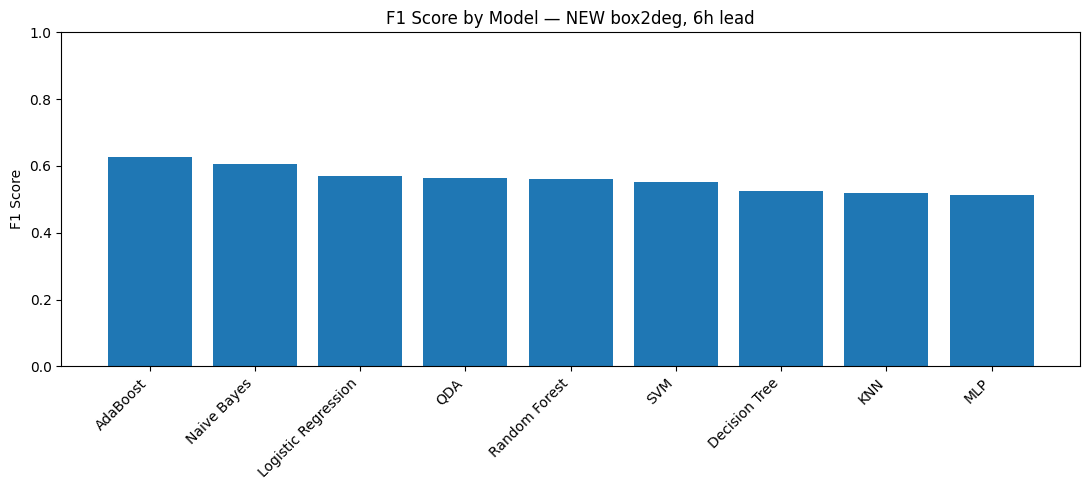

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_f1_6h.png


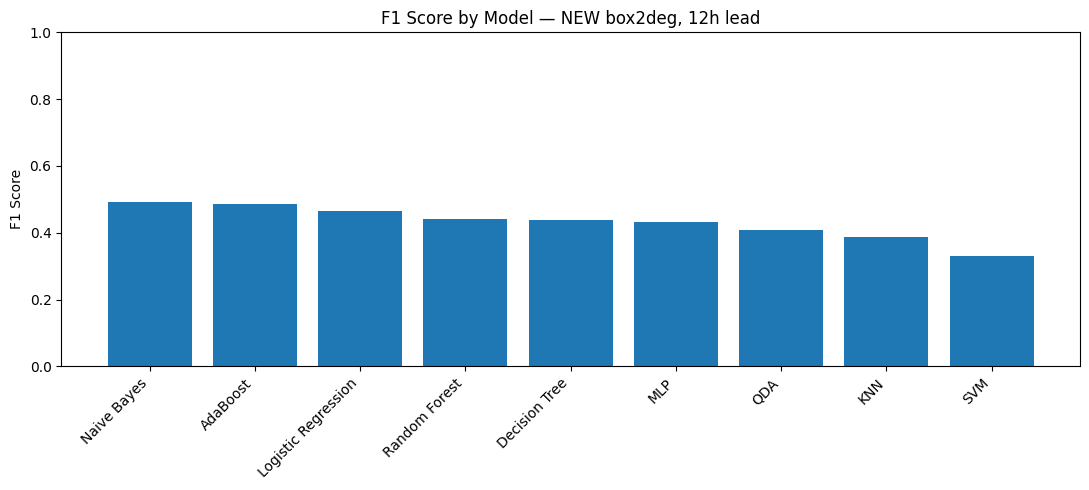

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_f1_12h.png


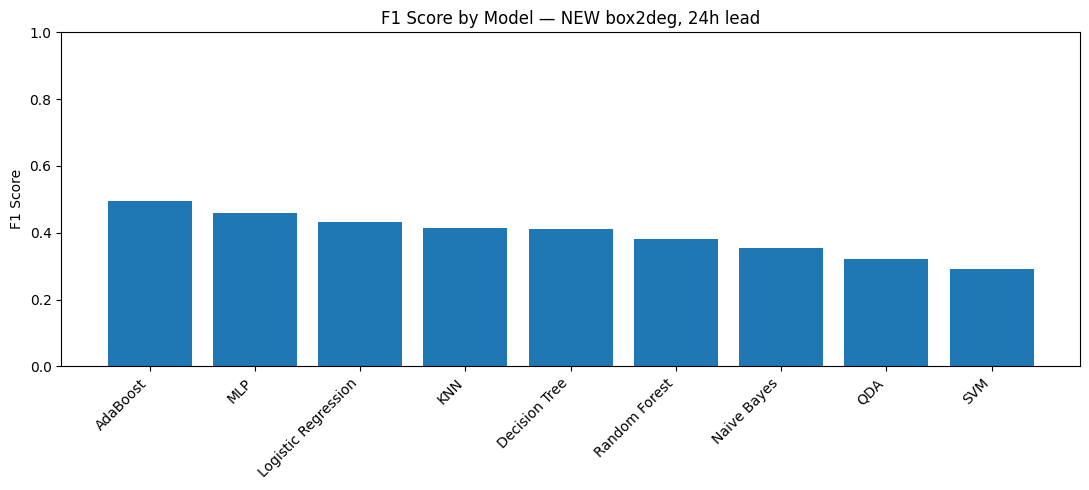

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_f1_24h.png


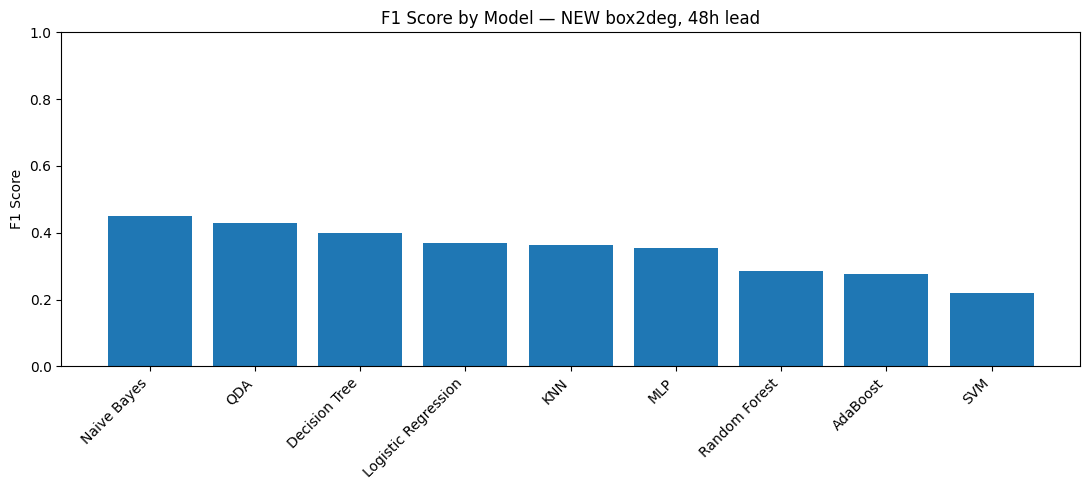

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_f1_48h.png


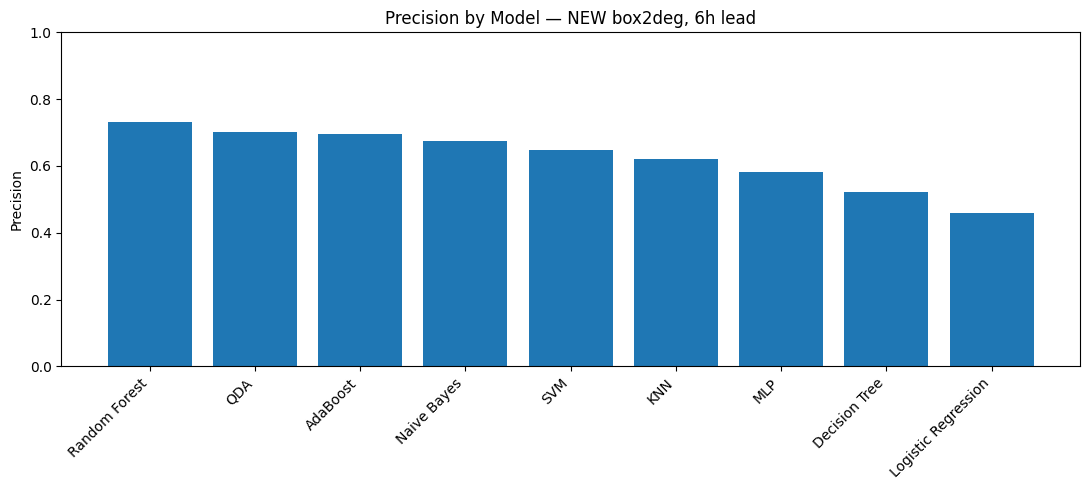

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_precision_6h.png


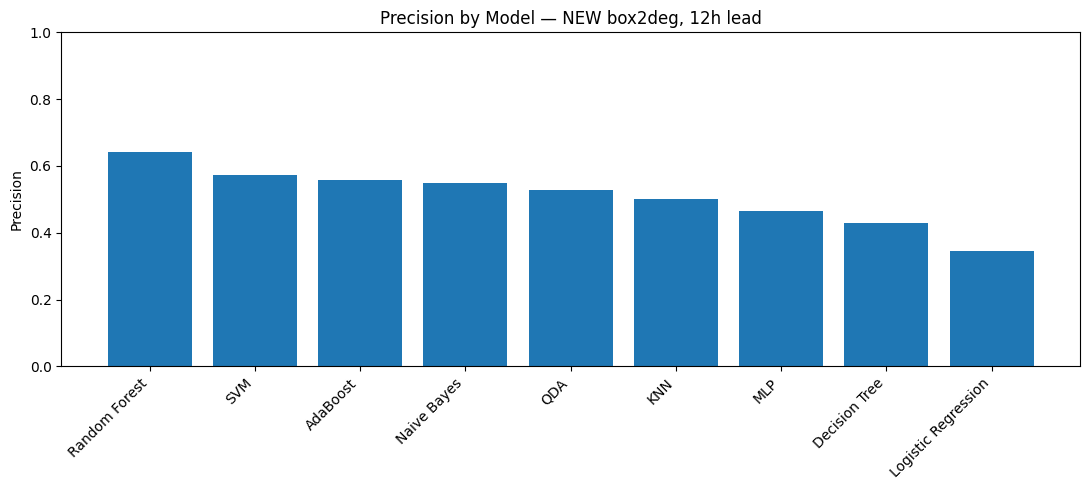

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_precision_12h.png


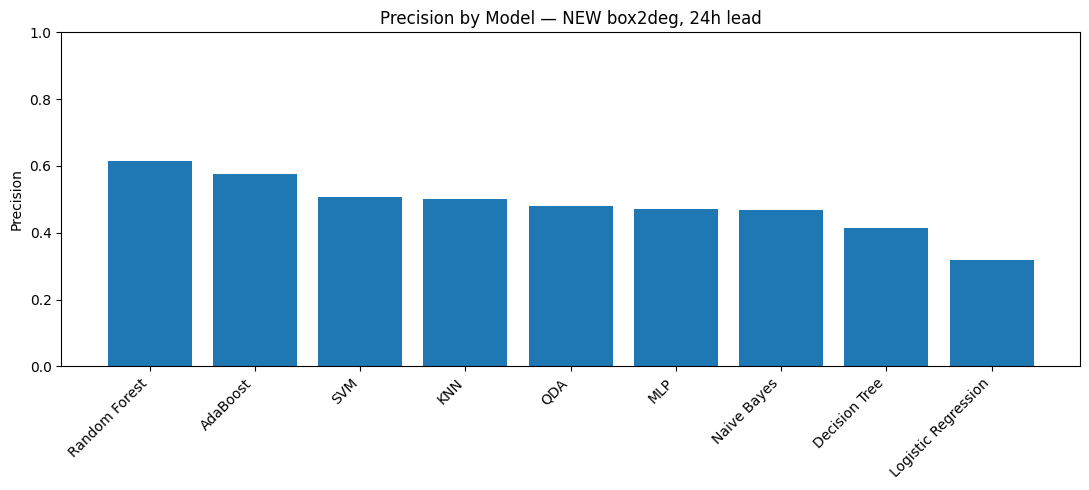

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_precision_24h.png


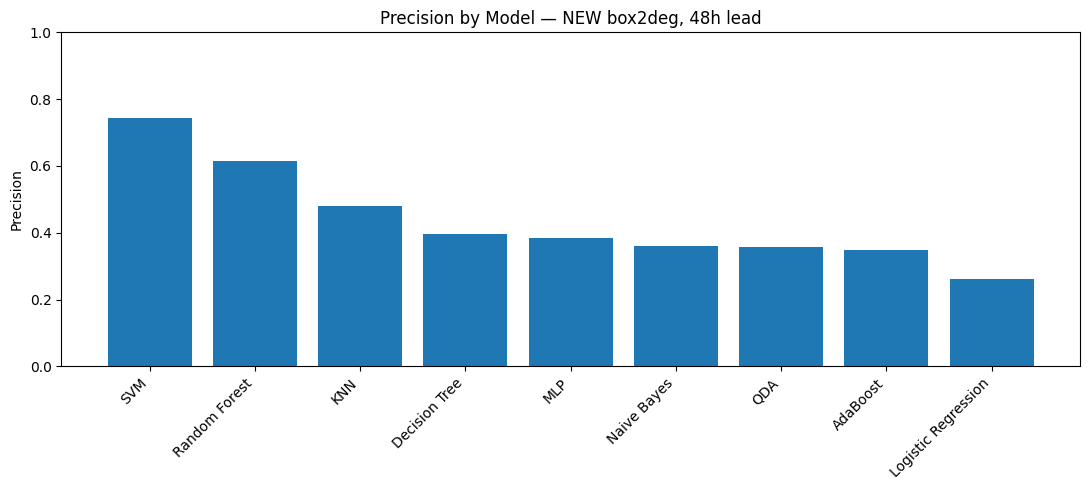

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_precision_48h.png


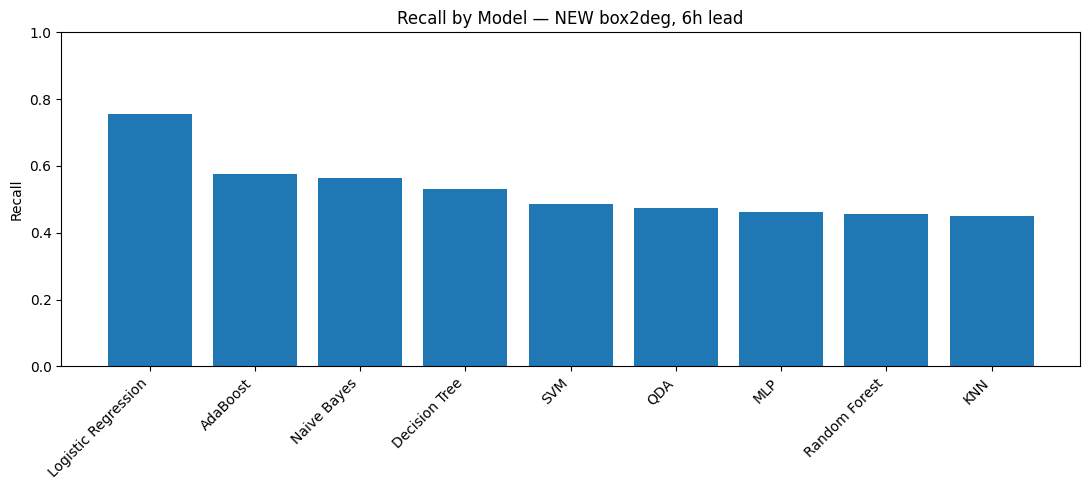

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_recall_6h.png


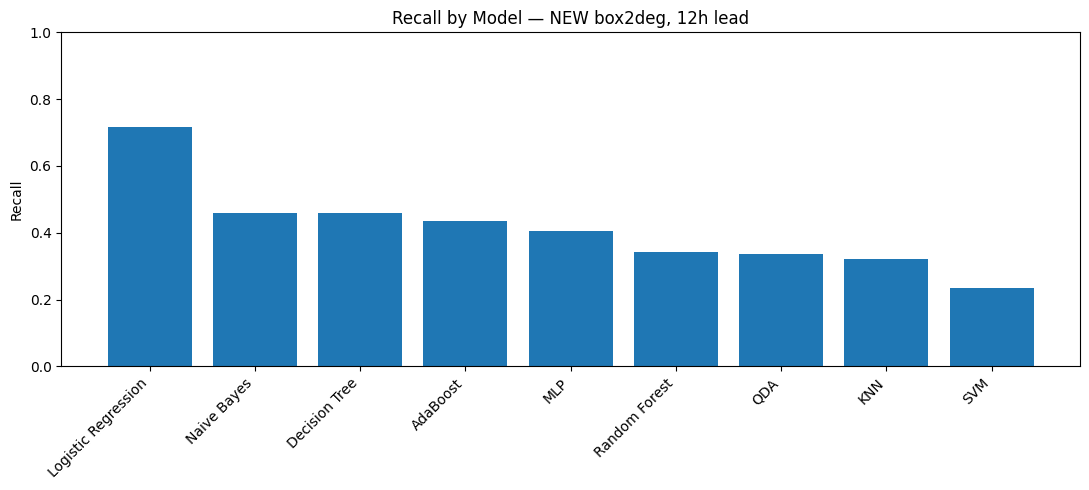

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_recall_12h.png


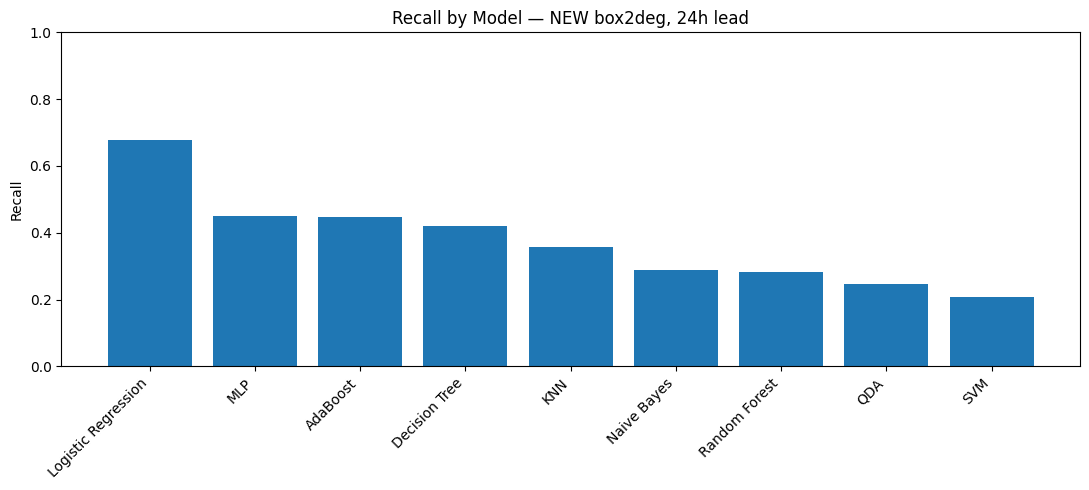

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_recall_24h.png


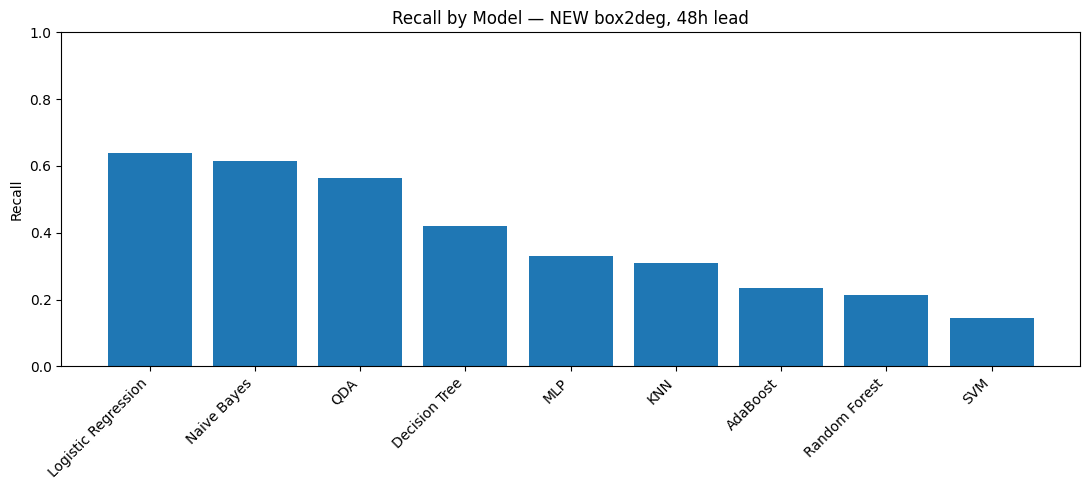

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\bar_recall_48h.png


In [30]:
# ============================================================
# BAR PLOTS FOR F1 / PRECISION / RECALL
# ============================================================

import matplotlib.pyplot as plt

def plot_metric_by_lead(metric_col, ylabel, filename_prefix):
    for L in LEADS:
        sub = cv_summary[cv_summary["lead_h"] == L].copy()
        sub = sub.sort_values(metric_col, ascending=False)

        plt.figure(figsize=(11, 5))
        plt.bar(sub["model"], sub[metric_col])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel(ylabel)
        plt.title(f"{ylabel} by Model — {DATASET_NAME.upper()} {LABEL_NAME}, {L}h lead")
        plt.ylim(0, max(1.0, sub[metric_col].max() * 1.15))
        plt.tight_layout()

        out_fp = OUT_DIR / f"{filename_prefix}_{L}h.png"
        plt.savefig(out_fp, dpi=200)
        plt.show()

        print("Saved:", out_fp)

plot_metric_by_lead("f1_mean", "F1 Score", "bar_f1")
plot_metric_by_lead("precision_mean", "Precision", "bar_precision")
plot_metric_by_lead("recall_mean", "Recall", "bar_recall")

In [31]:
# ============================================================
# GPI-ONLY THRESHOLD BASELINE
# ============================================================

def gpi_threshold_baseline(case_csv, lead_h):
    df = pd.read_csv(case_csv)
    df = df.dropna(subset=["gpi"]).copy()

    y = df["y"].astype(int).values
    score = df["gpi"].astype(float).values

    scan = threshold_scan(y, score)

    if len(scan) == 0:
        return pd.DataFrame(), pd.DataFrame()

    best = scan.iloc[[0]].copy()
    best["dataset"] = DATASET_NAME
    best["label"] = LABEL_NAME
    best["lead_h"] = lead_h
    best["model"] = "GPI threshold"

    scan["dataset"] = DATASET_NAME
    scan["label"] = LABEL_NAME
    scan["lead_h"] = lead_h
    scan["model"] = "GPI threshold"

    return scan, best


gpi_scans = []
gpi_bests = []

for L in LEADS:
    case_csv = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    scan, best = gpi_threshold_baseline(case_csv, L)

    if len(scan) > 0:
        scan.to_csv(OUT_DIR / f"gpi_threshold_scan_{L}h.csv", index=False)
        gpi_scans.append(scan)
        gpi_bests.append(best)

if gpi_bests:
    gpi_best = pd.concat(gpi_bests, ignore_index=True)
    gpi_best.to_csv(OUT_DIR / "gpi_threshold_best_by_lead.csv", index=False)
    display(gpi_best[["lead_h", "model", "threshold", "f1", "precision", "recall", "roc_auc", "pr_auc"]])

,lead_h,model,threshold,f1,precision,recall,roc_auc,pr_auc
0,6,GPI threshold,28.608261,0.576803,0.550898,0.605263,0.828160,0.601701
1,12,GPI threshold,22.199162,0.544872,0.488506,0.615942,0.819395,0.501169
2,24,GPI threshold,12.300251,0.517572,0.399015,0.736364,0.788141,0.453561
3,48,GPI threshold,3.569619,0.414861,0.272358,0.870130,0.690560,0.288486


PLOTTINGGGGG

In [45]:


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import gaussian_kde
from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
DATASET_NAME = "new"
LABEL_NAME = "box2deg"
CASE_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output_softtest\exactlead_box2deg_case_tables_new_2009_2025_UPDATED"
)

OUT_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED"
)

PLOT_DIR = OUT_DIR / "plots_new"
CM_DIR = OUT_DIR / "confusion_matrices_new"
FI_DIR = OUT_DIR / "feature_importance_new"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)
FI_DIR.mkdir(parents=True, exist_ok=True)

LEADS = [6, 12, 24, 48]

FEATURE_COLS = [
    "lon", "lat", "month",
    "area_km2", "tb_mean", "tb_min",
    "speed_kmh", "direction_deg",
    "eta850_abs", "rh600", "wshear_200_850",
    "pi_vmax_ms", "gpi"
]

ID_COLS = [
    "track_id", "time", "centroid_lon", "centroid_lat"
]

# ------------------------------------------------------------
# Load saved ML outputs
# ------------------------------------------------------------
fold_results = pd.read_csv(OUT_DIR / "fold_results_all_models.csv")
oof_all = pd.read_csv(OUT_DIR / "oof_predictions_all_models.csv")
oof_summary = pd.read_csv(OUT_DIR / "oof_summary_default_and_tuned_all_models.csv")
threshold_scans = pd.read_csv(OUT_DIR / "threshold_scans_all_models.csv")

oof_all["time"] = pd.to_datetime(oof_all["time"], errors="coerce", utc=True).dt.tz_convert(None)

print("Loaded:")
print("fold_results:", fold_results.shape)
print("oof_all:", oof_all.shape)
print("oof_summary:", oof_summary.shape)
print("threshold_scans:", threshold_scans.shape)

print("\nAvailable models:")
print(sorted(oof_all["model"].dropna().unique()))

Loaded:
fold_results: (180, 24)
oof_all: (28188, 13)
oof_summary: (72, 16)
threshold_scans: (13232, 15)

Available models:
['AdaBoost', 'Decision Tree', 'KNN', 'Logistic Regression', 'MLP', 'Naive Bayes', 'QDA', 'Random Forest', 'SVM']


In [46]:
# ============================================================
# LOAD NEW CASE TABLES
# ============================================================

datasets = {}

for L in LEADS:
    fp = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    if not fp.exists():
        raise FileNotFoundError(fp)

    df = pd.read_csv(fp)
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)
    df["y"] = df["y"].astype(int)

    datasets[L] = df.copy()

    print(f"\nLead {L}h")
    print("Rows:", len(df))
    print("Positive:", int(df["y"].sum()))
    print("Negative:", int((df["y"] == 0).sum()))
    print("Any predictor NaN fraction:", df[FEATURE_COLS].isna().any(axis=1).mean())


Lead 6h
Rows: 996
Positive: 166
Negative: 830
Any predictor NaN fraction: 0.5240963855421686

Lead 12h
Rows: 894
Positive: 149
Negative: 745
Any predictor NaN fraction: 0.5391498881431768

Lead 24h
Rows: 714
Positive: 119
Negative: 595
Any predictor NaN fraction: 0.542016806722689

Lead 48h
Rows: 528
Positive: 88
Negative: 440
Any predictor NaN fraction: 0.5738636363636364


In [47]:
# ============================================================
# SUMMARY TABLES
# ============================================================

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

# If cv_summary already exists, load it. Otherwise rebuild from fold_results.
cv_summary_fp = OUT_DIR / "cv_summary_mean_std_all_models.csv"

if cv_summary_fp.exists():
    cv_summary = pd.read_csv(cv_summary_fp)
else:
    summary_rows = []

    for (lead_h, model), g in fold_results.groupby(["lead_h", "model"]):
        row = {
            "dataset": DATASET_NAME,
            "label": LABEL_NAME,
            "lead_h": lead_h,
            "model": model,
            "folds": g["fold"].nunique(),
            "samples_mean": g["test_n"].mean(),
            "test_pos_mean": g["test_pos"].mean(),
            "test_neg_mean": g["test_neg"].mean(),
        }

        for metric in metric_cols:
            row[f"{metric}_mean"] = g[metric].mean()
            row[f"{metric}_std"] = g[metric].std()

        summary_rows.append(row)

    cv_summary = pd.DataFrame(summary_rows)
    cv_summary.to_csv(cv_summary_fp, index=False)

cv_summary = cv_summary.sort_values(["lead_h", "f1_mean"], ascending=[True, False]).reset_index(drop=True)

ranked_table = cv_summary[
    [
        "lead_h", "model",
        "precision_mean", "recall_mean", "f1_mean",
        "roc_auc_mean", "pr_auc_mean"
    ]
].copy()

ranked_table = ranked_table.rename(columns={
    "precision_mean": "precision",
    "recall_mean": "recall",
    "f1_mean": "f1",
    "roc_auc_mean": "roc_auc",
    "pr_auc_mean": "pr_auc",
})

ranked_table.to_csv(OUT_DIR / "model_performance_ranked_by_lead_old.csv", index=False)

best_by_lead = (
    ranked_table
    .sort_values(["lead_h", "f1"], ascending=[True, False])
    .groupby("lead_h", as_index=False)
    .first()
)

best_by_lead.to_csv(OUT_DIR / "best_model_by_lead_old.csv", index=False)

print("\nRanked table:")
display(ranked_table)

print("\nBest model by lead:")
display(best_by_lead)


Ranked table:


,lead_h,model,precision,recall,f1,roc_auc,pr_auc
0,6,AdaBoost,0.695353,0.575765,0.627238,0.897832,0.662549
1,6,Naive Bayes,0.673972,0.563338,0.607036,0.869922,0.617785
2,6,Logistic Regression,0.460091,0.756314,0.569402,0.856204,0.598035
3,6,QDA,0.700409,0.475510,0.563177,0.873262,0.629682
4,6,Random Forest,0.732536,0.455914,0.561701,0.907674,0.687789
5,6,SVM,0.647692,0.485188,0.552423,0.890161,0.648458
6,6,Decision Tree,0.520549,0.531886,0.525255,0.717126,0.360449
7,6,KNN,0.621416,0.448629,0.519924,0.815040,0.487134
8,6,MLP,0.582028,0.463176,0.513847,0.854960,0.533521
9,12,Naive Bayes,0.549367,0.459769,0.492506,0.832530,0.496504



Best model by lead:


,lead_h,model,precision,recall,f1,roc_auc,pr_auc
0,6,AdaBoost,0.695353,0.575765,0.627238,0.897832,0.662549
1,12,Naive Bayes,0.549367,0.459769,0.492506,0.832530,0.496504
2,24,AdaBoost,0.576479,0.445698,0.496480,0.849130,0.567143
3,48,Naive Bayes,0.360026,0.613737,0.449380,0.759184,0.435889


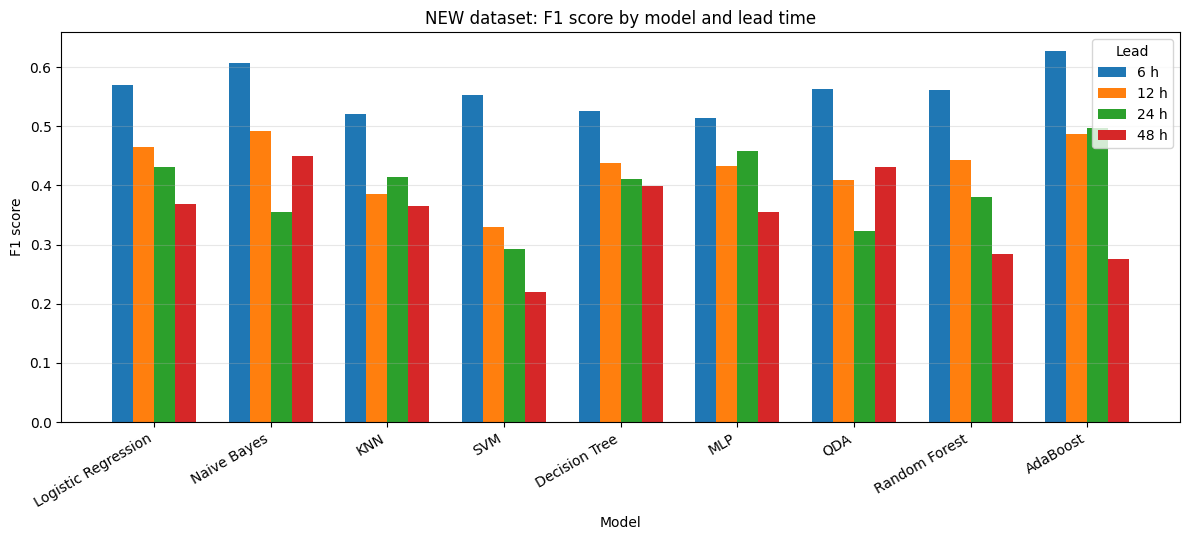

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\plots_new\bar_f1_by_model_lead_new.png


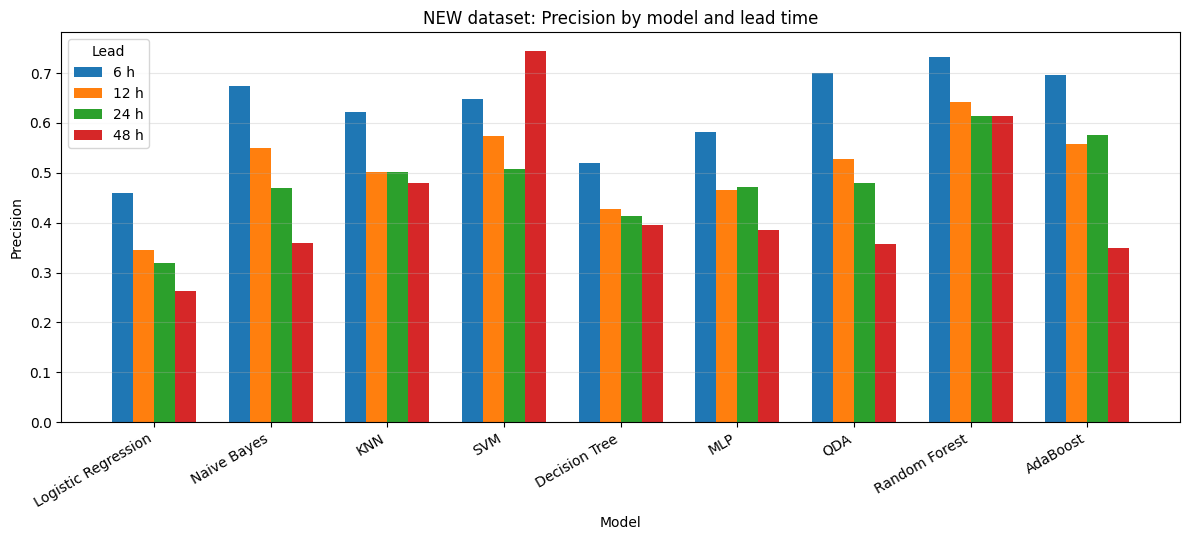

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\plots_new\bar_precision_by_model_lead_new.png


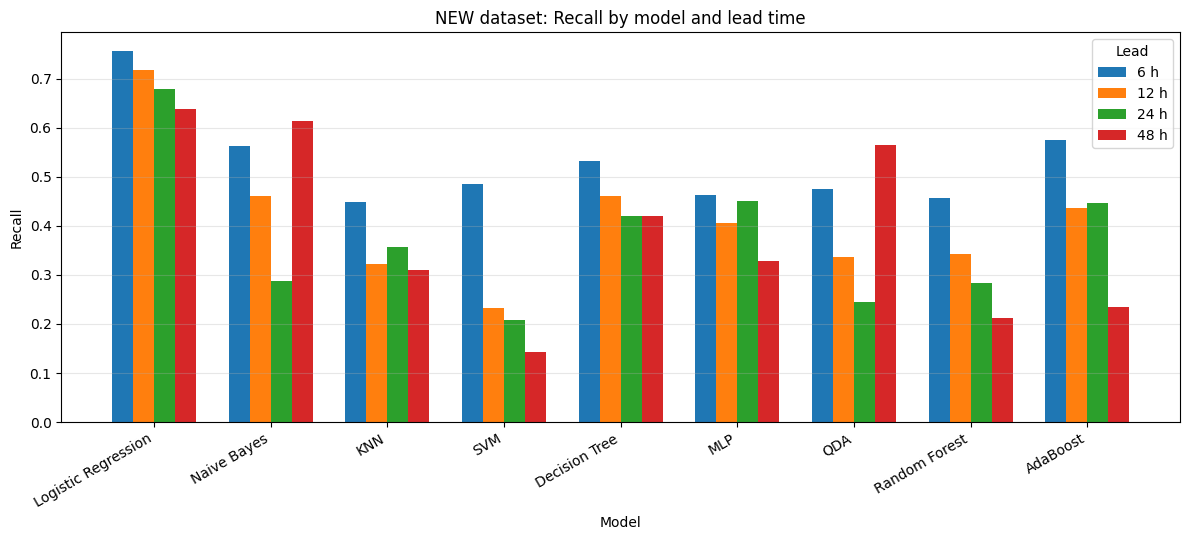

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\plots_new\bar_recall_by_model_lead_new.png


In [48]:
# ============================================================
# GROUPED BAR PLOTS — NEW
# F1, Precision, Recall
# ============================================================

MODEL_ORDER = [
    "Logistic Regression",
    "Naive Bayes",
    "KNN",
    "SVM",
    "Decision Tree",
    "MLP",
    "QDA",
    "Random Forest",
    "AdaBoost",
]

summary_plot = cv_summary.copy()
summary_plot["model"] = pd.Categorical(summary_plot["model"], categories=MODEL_ORDER, ordered=True)
summary_plot = summary_plot.sort_values(["model", "lead_h"]).copy()

lead_order = [6, 12, 24, 48]


def make_bar_metric(metric_col, ylabel, title, outname):
    piv = summary_plot.pivot(index="model", columns="lead_h", values=metric_col)
    piv = piv.reindex(MODEL_ORDER)
    piv = piv[lead_order]

    x = np.arange(len(piv.index))
    width = 0.18

    fig, ax = plt.subplots(figsize=(12, 5.5))

    for i, lead in enumerate(lead_order):
        ax.bar(
            x + (i - 1.5) * width,
            piv[lead],
            width=width,
            label=f"{lead} h"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(piv.index, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Model")
    ax.set_title(title)
    ax.legend(title="Lead")
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(PLOT_DIR / outname, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", PLOT_DIR / outname)


make_bar_metric(
    metric_col="f1_mean",
    ylabel="F1 score",
    title="NEW dataset: F1 score by model and lead time",
    outname="bar_f1_by_model_lead_new.png"
)

make_bar_metric(
    metric_col="precision_mean",
    ylabel="Precision",
    title="NEW dataset: Precision by model and lead time",
    outname="bar_precision_by_model_lead_new.png"
)

make_bar_metric(
    metric_col="recall_mean",
    ylabel="Recall",
    title="NEW dataset: Recall by model and lead time",
    outname="bar_recall_by_model_lead_new.png"
)

Top models: ['Naive Bayes', 'AdaBoost', 'Logistic Regression', 'Decision Tree']


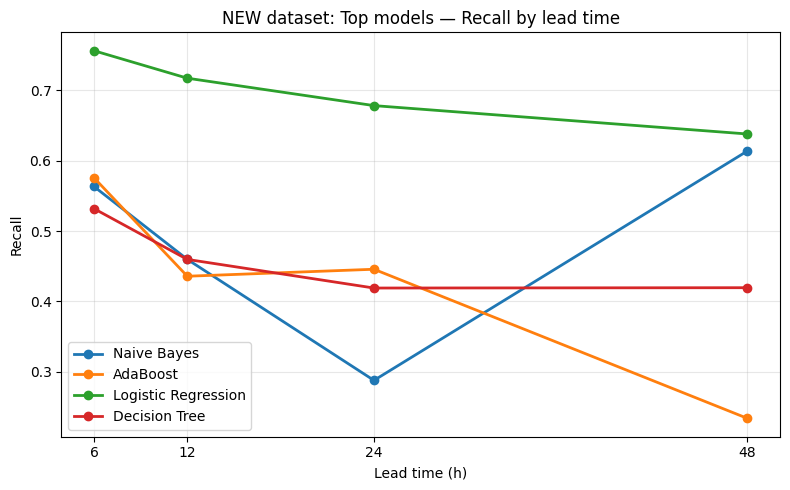

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\plots_new\top_models_recall_new.png


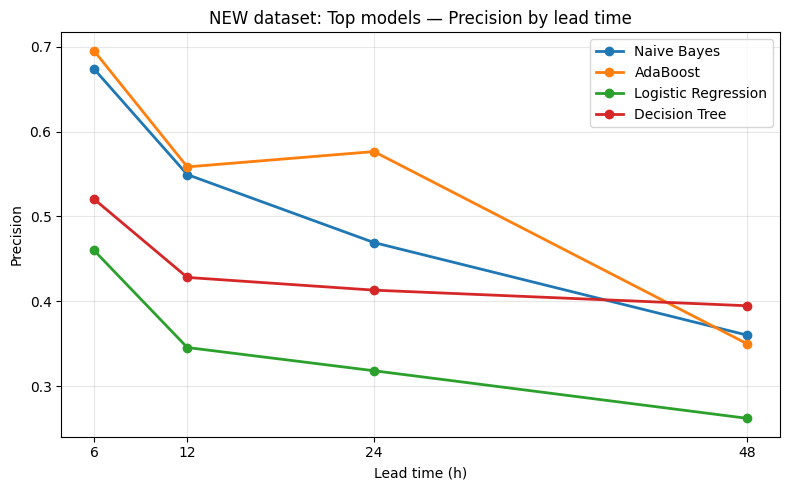

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\plots_new\top_models_precision_new.png


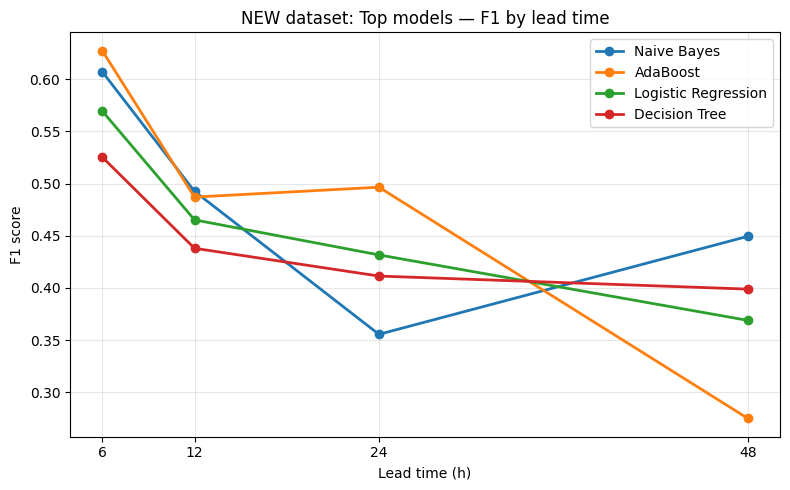

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\plots_new\top_models_f1_new.png


In [49]:
# ============================================================
# LINE PLOTS — TOP MODELS
# ============================================================

top_models = (
    cv_summary.groupby("model")["f1_mean"]
    .mean()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

print("Top models:", top_models)


def make_line_top(metric_col, ylabel, title, outname):
    fig, ax = plt.subplots(figsize=(8, 5))

    for model in top_models:
        sub = cv_summary[cv_summary["model"] == model].sort_values("lead_h")
        ax.plot(
            sub["lead_h"],
            sub[metric_col],
            marker="o",
            linewidth=2,
            label=model
        )

    ax.set_xticks(LEADS)
    ax.set_xlabel("Lead time (h)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOT_DIR / outname, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", PLOT_DIR / outname)


make_line_top(
    metric_col="recall_mean",
    ylabel="Recall",
    title="NEW dataset: Top models — Recall by lead time",
    outname="top_models_recall_new.png"
)

make_line_top(
    metric_col="precision_mean",
    ylabel="Precision",
    title="NEW dataset: Top models — Precision by lead time",
    outname="top_models_precision_new.png"
)

make_line_top(
    metric_col="f1_mean",
    ylabel="F1 score",
    title="NEW dataset: Top models — F1 by lead time",
    outname="top_models_f1_new.png"
)

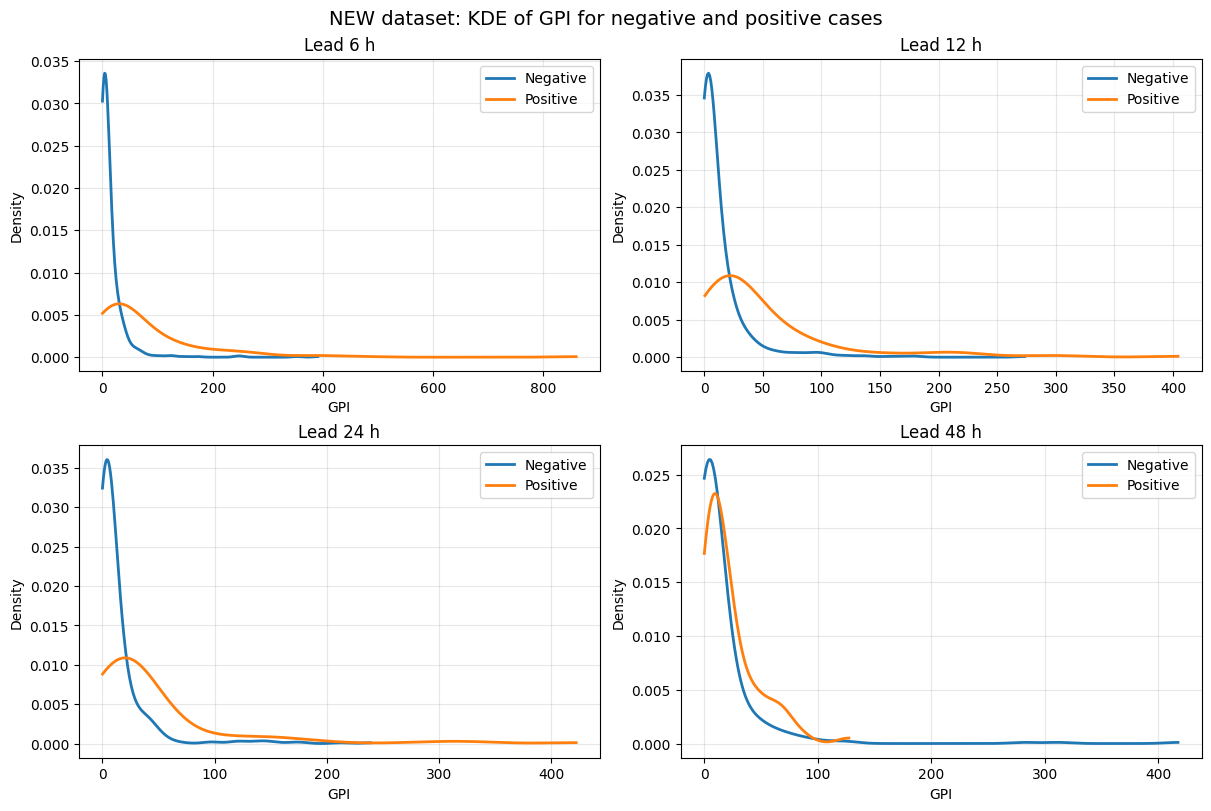

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\plots_new\gpi_kde_positive_negative_new.png


In [50]:
# ============================================================
# GPI KDE — NEW
# Positive vs Negative by lead
# ============================================================

GPI_COL = "gpi"

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

for ax, lead in zip(axes, LEADS):
    df = datasets[lead].copy()
    df = df.dropna(subset=[GPI_COL])

    neg = df.loc[df["y"] == 0, GPI_COL].astype(float).values
    pos = df.loc[df["y"] == 1, GPI_COL].astype(float).values

    if len(neg) > 5 and np.nanmax(neg) > np.nanmin(neg):
        xs = np.linspace(np.nanmin(neg), np.nanmax(neg), 300)
        kde = gaussian_kde(neg)
        ax.plot(xs, kde(xs), linewidth=2, label="Negative")

    if len(pos) > 5 and np.nanmax(pos) > np.nanmin(pos):
        xs = np.linspace(np.nanmin(pos), np.nanmax(pos), 300)
        kde = gaussian_kde(pos)
        ax.plot(xs, kde(xs), linewidth=2, label="Positive")

    ax.set_title(f"Lead {lead} h")
    ax.set_xlabel("GPI")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("NEW dataset: KDE of GPI for negative and positive cases", fontsize=14)
plt.savefig(PLOT_DIR / "gpi_kde_positive_negative_new.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", PLOT_DIR / "gpi_kde_positive_negative_new.png")

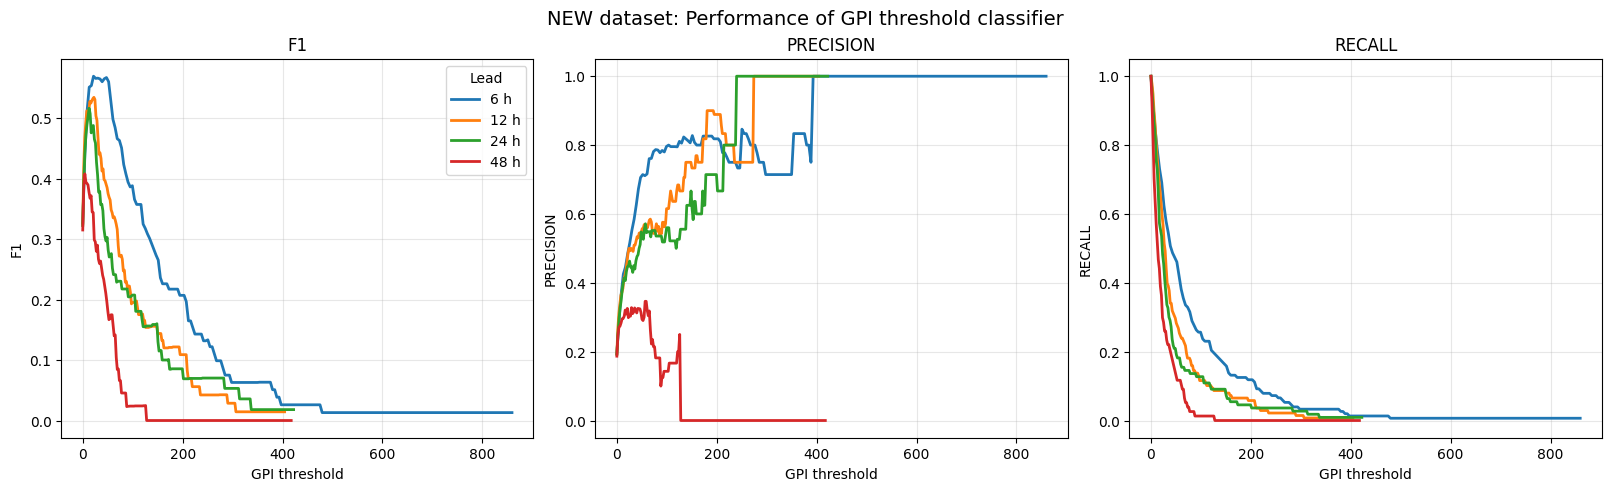


Best GPI threshold by lead:


,lead_h,threshold,f1,precision,recall
0,6,21.592498,0.569106,0.483871,0.690789
1,12,22.342578,0.534202,0.485207,0.594203
2,24,12.729356,0.516129,0.400000,0.727273
3,48,4.194576,0.407767,0.271552,0.818182


In [51]:
# ============================================================
# GPI THRESHOLD CLASSIFIER — NEW
# F1 / Precision / Recall vs GPI threshold
# ============================================================

rows = []

for lead in LEADS:
    df = datasets[lead].copy()
    df = df.dropna(subset=[GPI_COL])

    y_true = df["y"].astype(int).values
    gpi = df[GPI_COL].astype(float).values

    if len(df) == 0:
        continue

    thresholds = np.linspace(np.nanmin(gpi), np.nanmax(gpi), 200)

    for thr in thresholds:
        y_pred = (gpi >= thr).astype(int)

        rows.append({
            "lead_h": lead,
            "threshold": thr,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

gpi_perf = pd.DataFrame(rows)
gpi_perf.to_csv(OUT_DIR / "gpi_threshold_performance_old.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
metric_list = ["f1", "precision", "recall"]

for ax, metric in zip(axes, metric_list):
    for lead in LEADS:
        sub = gpi_perf[gpi_perf["lead_h"] == lead]
        ax.plot(sub["threshold"], sub[metric], linewidth=2, label=f"{lead} h")

    ax.set_title(metric.upper())
    ax.set_xlabel("GPI threshold")
    ax.set_ylabel(metric.upper())
    ax.grid(True, alpha=0.3)

axes[0].legend(title="Lead")
fig.suptitle("NEW dataset: Performance of GPI threshold classifier", fontsize=14)
plt.savefig(PLOT_DIR / "gpi_threshold_classifier_performance_new.png", dpi=220, bbox_inches="tight")
plt.show()

best_gpi = (
    gpi_perf.sort_values(["lead_h", "f1"], ascending=[True, False])
    .groupby("lead_h", as_index=False)
    .first()
)

best_gpi.to_csv(OUT_DIR / "best_gpi_threshold_by_lead_new.csv", index=False)

print("\nBest GPI threshold by lead:")
display(best_gpi[["lead_h", "threshold", "f1", "precision", "recall"]])

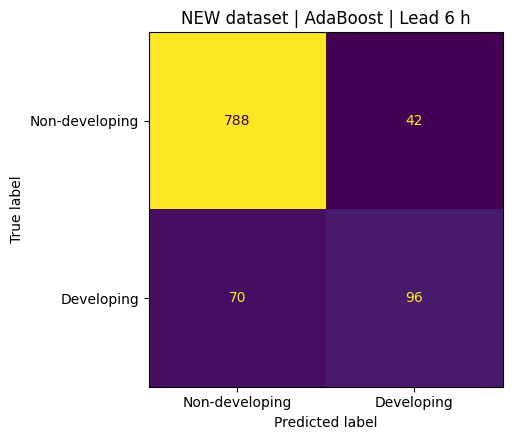

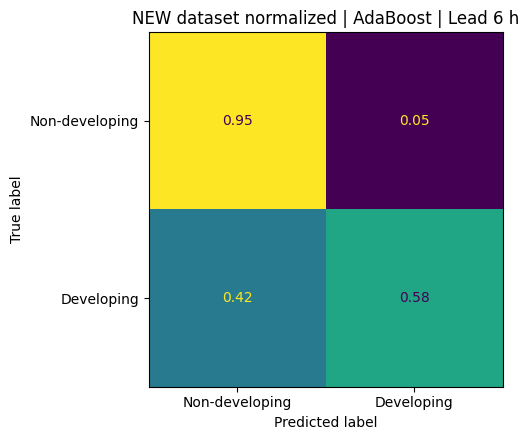

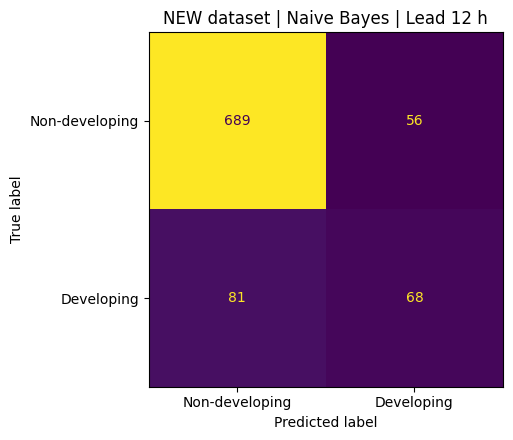

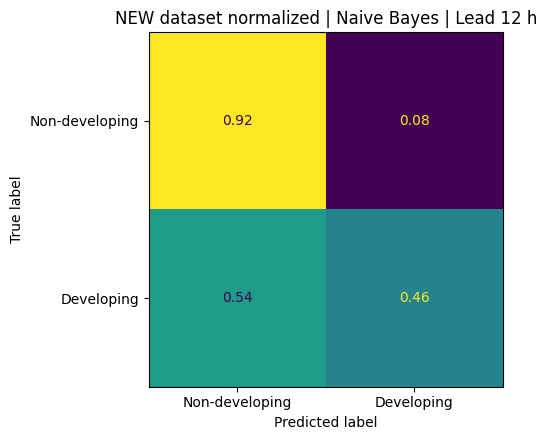

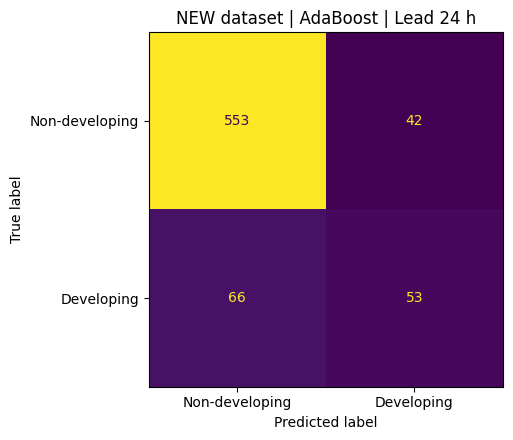

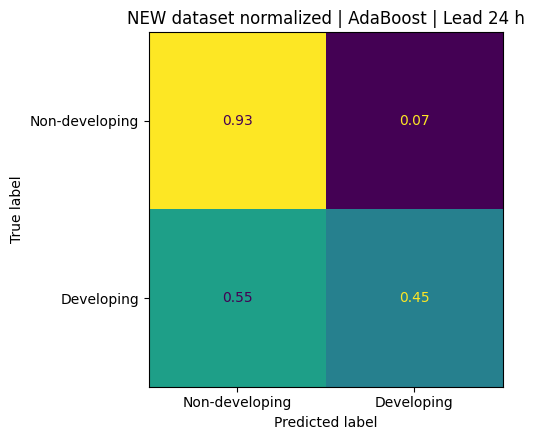

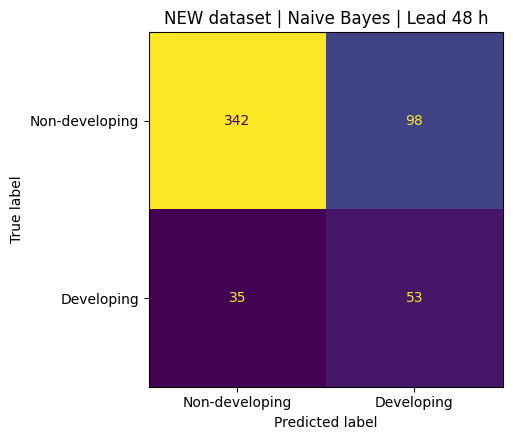

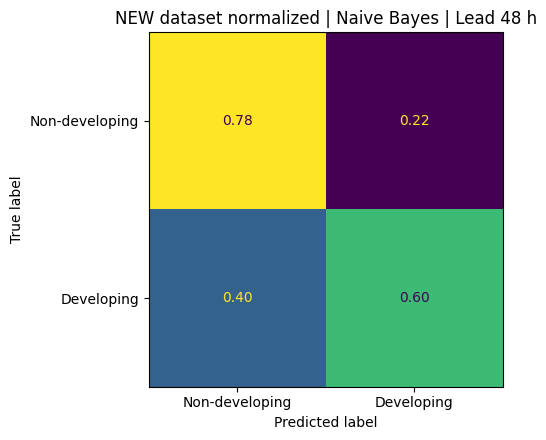

,lead_h,model,tn,fp,fn,tp,total
0,6,AdaBoost,788,42,70,96,996
1,12,Naive Bayes,689,56,81,68,894
2,24,AdaBoost,553,42,66,53,714
3,48,Naive Bayes,342,98,35,53,528


In [52]:
# ============================================================
# CONFUSION MATRICES — NEW BEST MODEL PER LEAD
# Uses OOF predictions from CV
# ============================================================

cm_rows = []

for _, row in best_by_lead.iterrows():
    lead = int(row["lead_h"])
    model_name = row["model"]

    sub = oof_all[
        (oof_all["lead_h"] == lead)
        & (oof_all["model"] == model_name)
    ].copy()

    y_true = sub["y_true"].astype(int).values

    # Use default prediction if available
    if "y_pred_default" in sub.columns:
        y_pred = sub["y_pred_default"].astype(int).values
    elif "y_pred" in sub.columns:
        y_pred = sub["y_pred"].astype(int).values
    else:
        y_pred = (sub["y_score"].astype(float).values >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cm_rows.append({
        "lead_h": lead,
        "model": model_name,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "total": int(cm.sum()),
    })

    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    ConfusionMatrixDisplay(
        cm,
        display_labels=["Non-developing", "Developing"]
    ).plot(ax=ax, colorbar=False, values_format="d")

    ax.set_title(f"NEW dataset | {model_name} | Lead {lead} h")
    plt.tight_layout()

    safe_model = model_name.replace(" ", "_").replace("/", "_")
    out_png = CM_DIR / f"confusion_matrix_new_{safe_model}_{lead}h.png"

    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

    # Normalized
    cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize="true")

    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    ConfusionMatrixDisplay(
        cm_norm,
        display_labels=["Non-developing", "Developing"]
    ).plot(ax=ax, colorbar=False, values_format=".2f")

    ax.set_title(f"NEW dataset normalized | {model_name} | Lead {lead} h")
    plt.tight_layout()

    out_png_norm = CM_DIR / f"confusion_matrix_new_normalized_{safe_model}_{lead}h.png"

    plt.savefig(out_png_norm, dpi=220, bbox_inches="tight")
    plt.show()

cm_table = pd.DataFrame(cm_rows)
cm_table.to_csv(CM_DIR / "confusion_matrix_values_best_models_new.csv", index=False)

cm_table

Available models in oof_all:
['AdaBoost', 'Decision Tree', 'KNN', 'Logistic Regression', 'MLP', 'Naive Bayes', 'QDA', 'Random Forest', 'SVM']


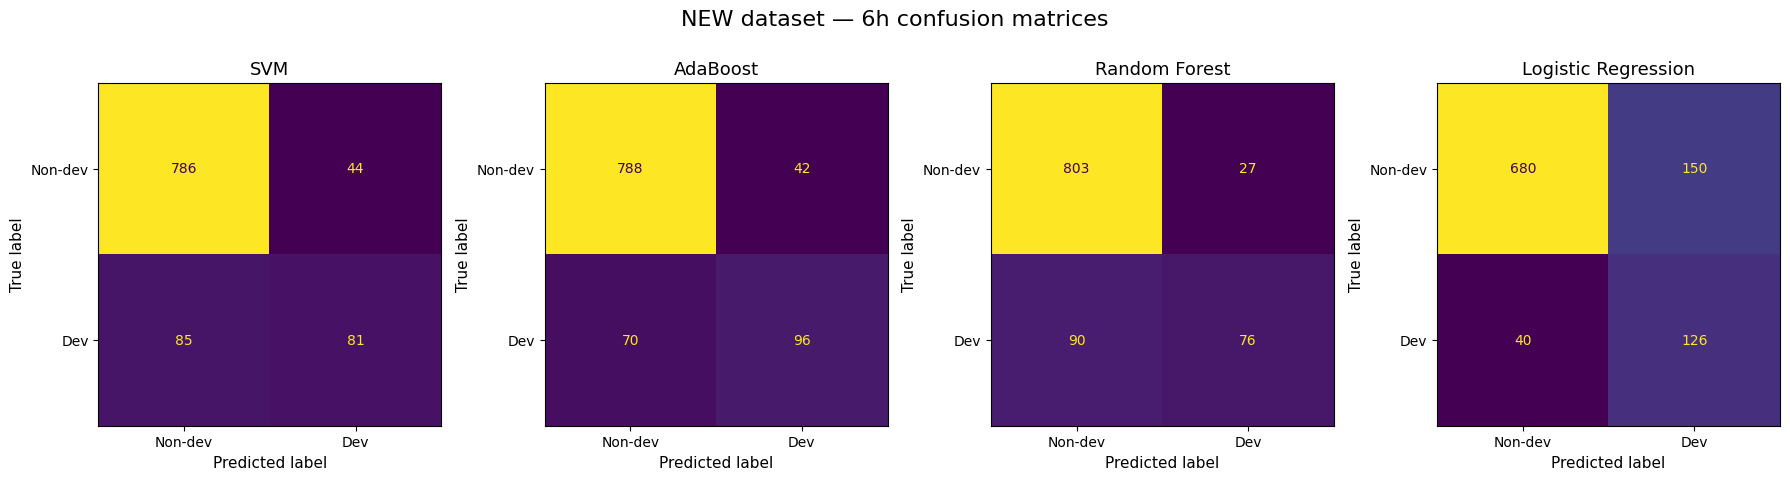

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\confusion_matrices_new\combined_figures\new_6h_confusion_matrices_1x4_SVM_AdaBoost_RandomForest_Logistic.png


,dataset,model,lead_h,rows,tn,fp,fn,tp
0,new,SVM,6,996,786,44,85,81
1,new,AdaBoost,6,996,788,42,70,96
2,new,Random Forest,6,996,803,27,90,76
3,new,Logistic Regression,6,996,680,150,40,126


In [53]:
# ============================================================
# NEW — 6H CONFUSION MATRICES IN ONE 1x4 FIGURE
# SVM, AdaBoost, Random Forest, Logistic Regression
# Uses OOF predictions from 5-fold CV
# ============================================================

LEAD = 6

MODELS_6H = [
    "SVM",
    "AdaBoost",
    "Random Forest",
    "Logistic Regression",
]

OUT_ONEFIG_DIR = CM_DIR / "combined_figures"
OUT_ONEFIG_DIR.mkdir(parents=True, exist_ok=True)

print("Available models in oof_all:")
print(sorted(oof_all["model"].unique()))

missing_models = [m for m in MODELS_6H if m not in oof_all["model"].unique()]
if missing_models:
    raise ValueError(
        f"Missing models in oof_all: {missing_models}\n"
        f"Available models: {sorted(oof_all['model'].unique())}"
    )

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes = axes.flatten()

cm_rows_6h = []

for ax, model_name in zip(axes, MODELS_6H):
    sub = oof_all[
        (oof_all["lead_h"] == LEAD)
        & (oof_all["model"] == model_name)
    ].copy()

    y_true = sub["y_true"].astype(int).values

    if "y_pred_default" in sub.columns:
        y_pred = sub["y_pred_default"].astype(int).values
    elif "y_pred" in sub.columns:
        y_pred = sub["y_pred"].astype(int).values
    else:
        y_pred = (sub["y_score"].astype(float).values >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cm_rows_6h.append({
        "dataset": "new",
        "model": model_name,
        "lead_h": LEAD,
        "rows": len(sub),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    })

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-dev", "Dev"]
    ).plot(
        ax=ax,
        colorbar=False,
        values_format="d"
    )

    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)

fig.suptitle("NEW dataset — 6h confusion matrices", fontsize=16, y=1.03)
plt.tight_layout()

out_png = OUT_ONEFIG_DIR / "new_6h_confusion_matrices_1x4_SVM_AdaBoost_RandomForest_Logistic.png"
plt.savefig(out_png, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_png)

cm_summary_new_6h = pd.DataFrame(cm_rows_6h)
cm_summary_new_6h.to_csv(
    OUT_ONEFIG_DIR / "new_6h_confusion_matrix_values.csv",
    index=False
)

cm_summary_new_6h

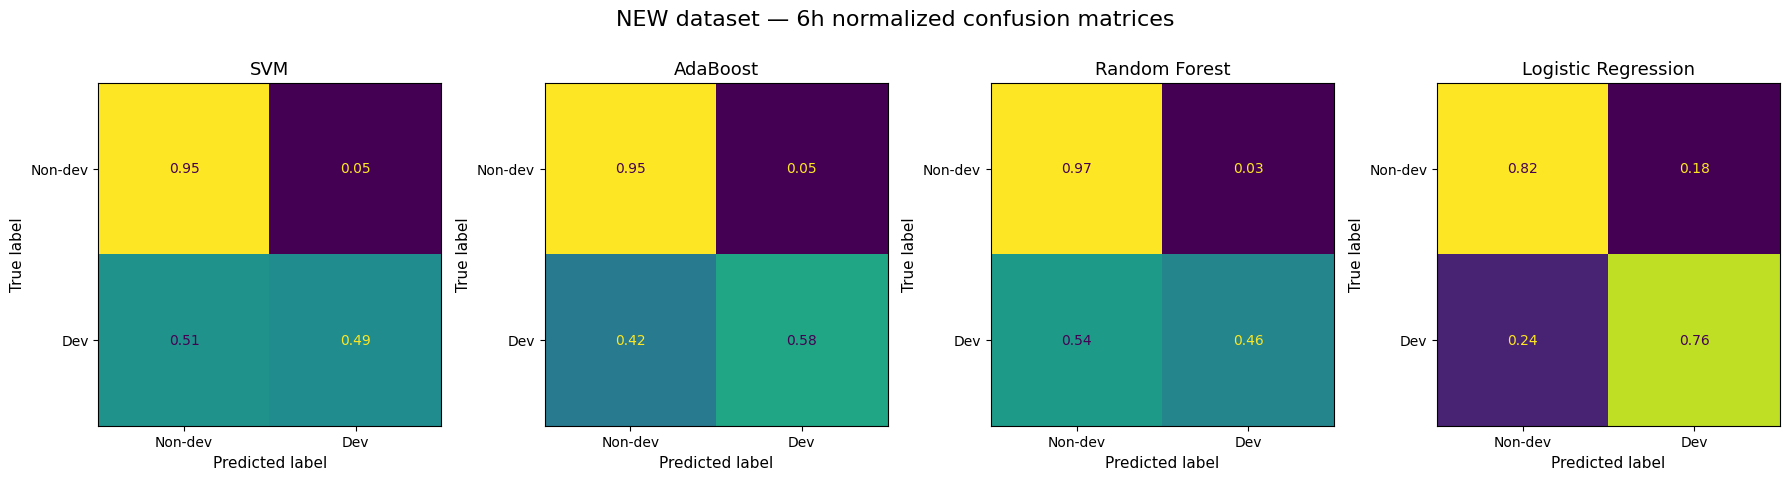

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\confusion_matrices_new\combined_figures\new_6h_confusion_matrices_1x4_normalized_SVM_AdaBoost_RandomForest_Logistic.png


In [54]:
# ============================================================
# NEW — 6H NORMALIZED CONFUSION MATRICES IN ONE 1x4 FIGURE
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes = axes.flatten()

for ax, model_name in zip(axes, MODELS_6H):
    sub = oof_all[
        (oof_all["lead_h"] == LEAD)
        & (oof_all["model"] == model_name)
    ].copy()

    y_true = sub["y_true"].astype(int).values

    if "y_pred_default" in sub.columns:
        y_pred = sub["y_pred_default"].astype(int).values
    elif "y_pred" in sub.columns:
        y_pred = sub["y_pred"].astype(int).values
    else:
        y_pred = (sub["y_score"].astype(float).values >= 0.5).astype(int)

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
        normalize="true"
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=["Non-dev", "Dev"]
    ).plot(
        ax=ax,
        colorbar=False,
        values_format=".2f"
    )

    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)

fig.suptitle("NEW dataset — 6h normalized confusion matrices", fontsize=16, y=1.03)
plt.tight_layout()

out_png_norm = OUT_ONEFIG_DIR / "new_6h_confusion_matrices_1x4_normalized_SVM_AdaBoost_RandomForest_Logistic.png"
plt.savefig(out_png_norm, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_png_norm)

Feature importance: Random Forest, lead 6h


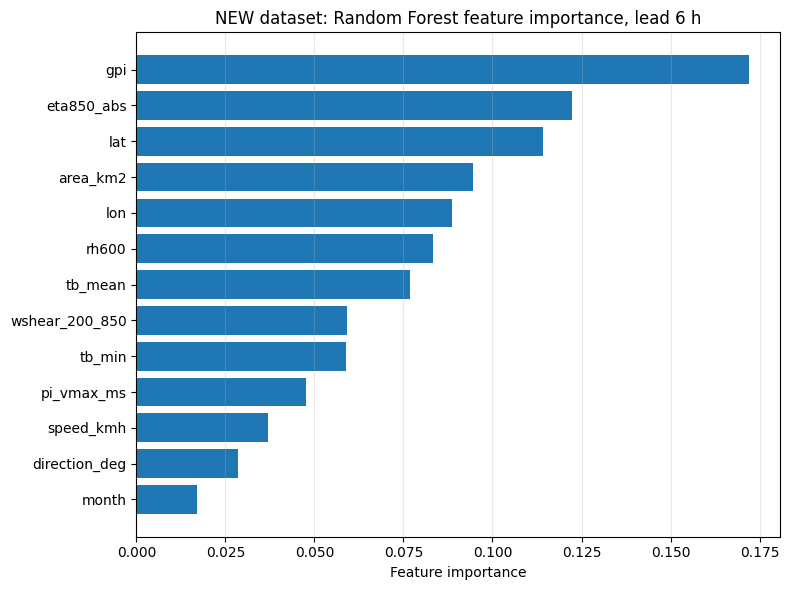

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_Random_Forest_6h.png
Feature importance: AdaBoost, lead 6h


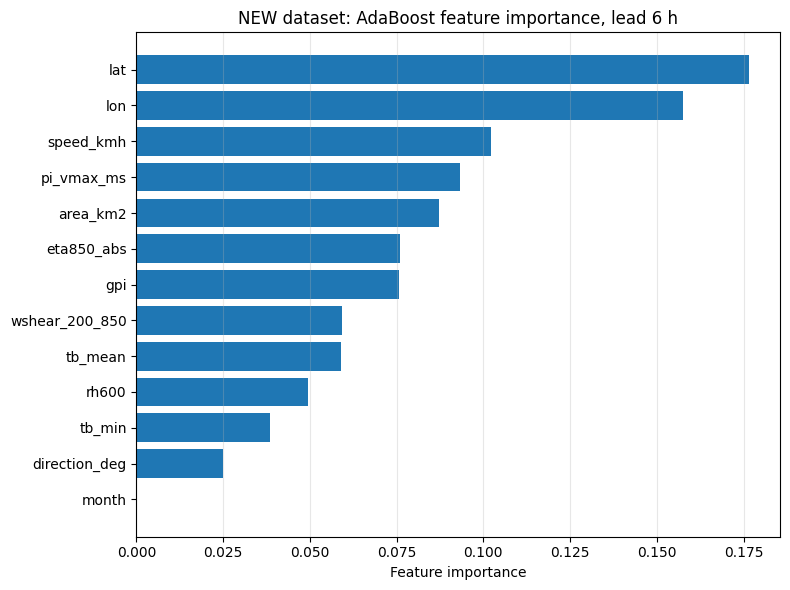

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_AdaBoost_6h.png
Feature importance: Decision Tree, lead 6h


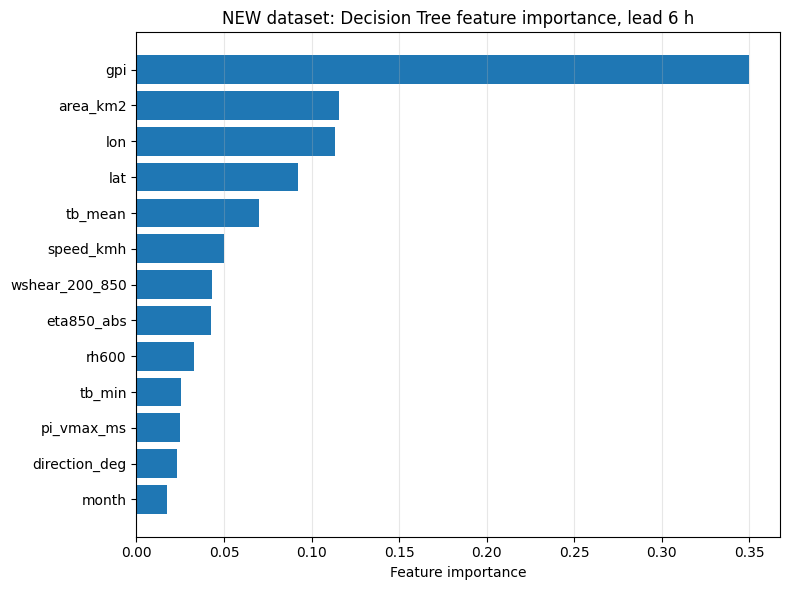

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_Decision_Tree_6h.png
Feature importance: Random Forest, lead 12h


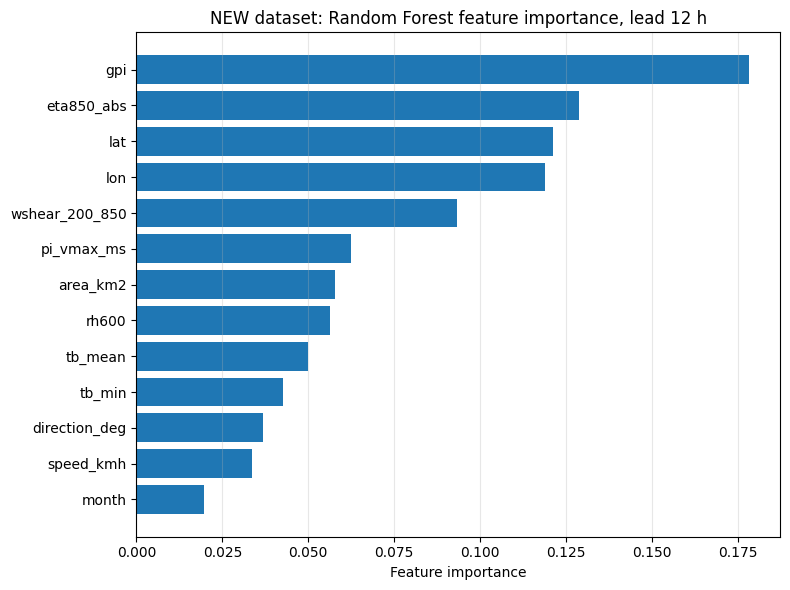

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_Random_Forest_12h.png
Feature importance: AdaBoost, lead 12h


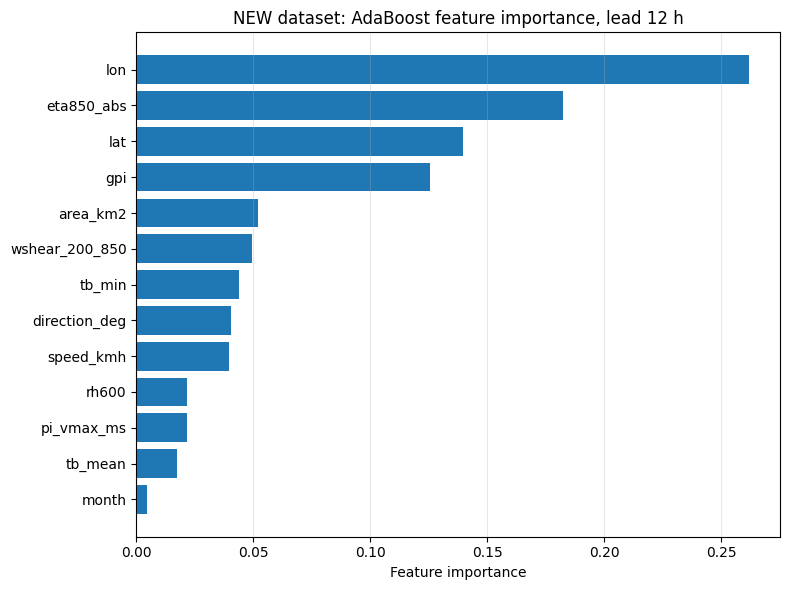

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_AdaBoost_12h.png
Feature importance: Decision Tree, lead 12h


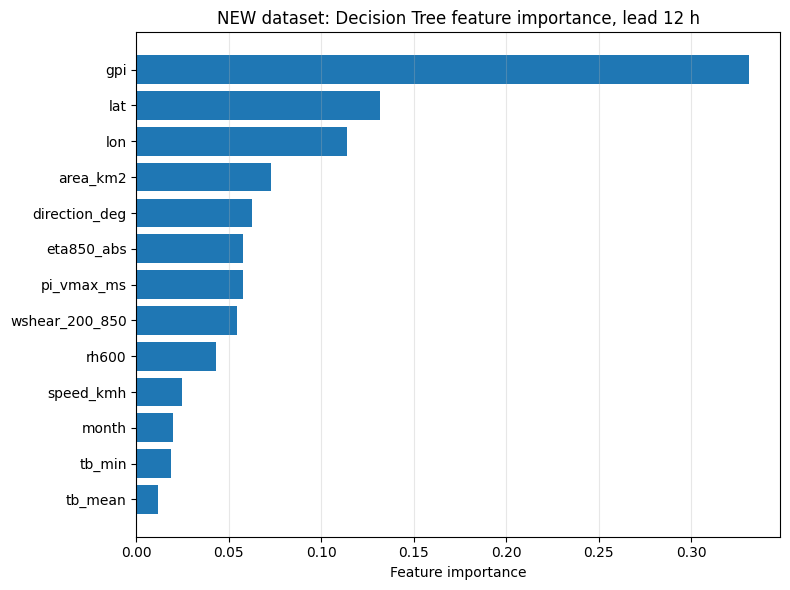

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_Decision_Tree_12h.png
Feature importance: Random Forest, lead 24h


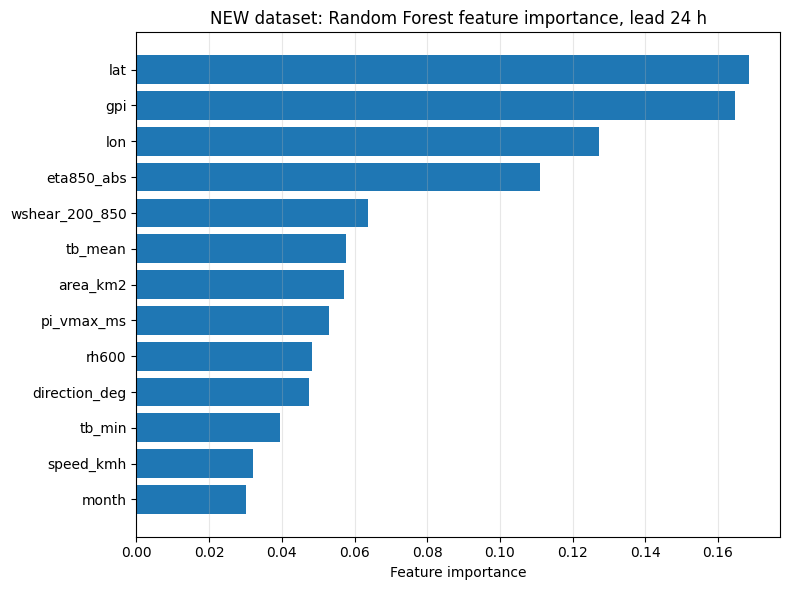

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_Random_Forest_24h.png
Feature importance: AdaBoost, lead 24h


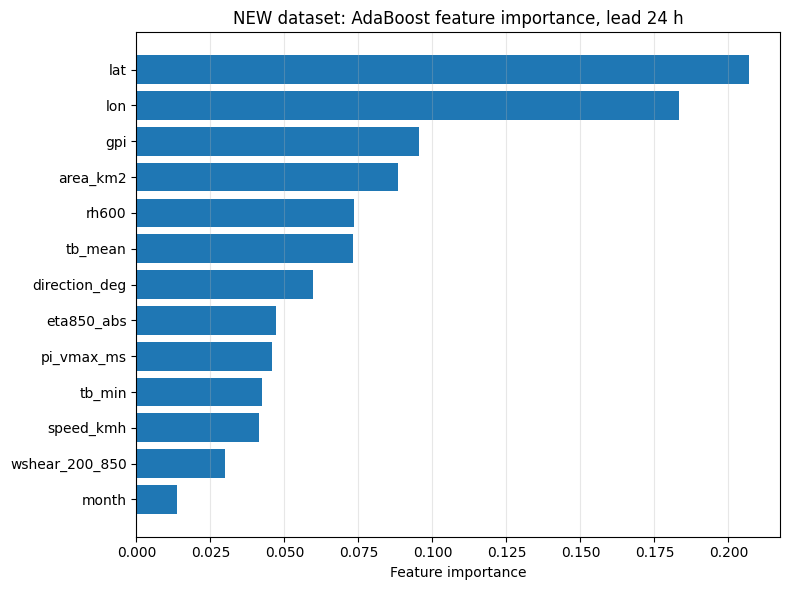

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_AdaBoost_24h.png
Feature importance: Decision Tree, lead 24h


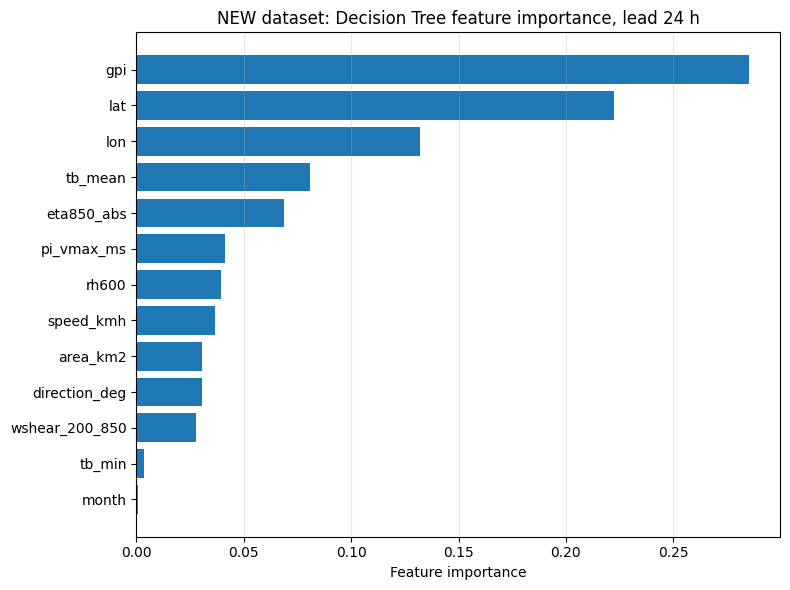

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_Decision_Tree_24h.png
Feature importance: Random Forest, lead 48h


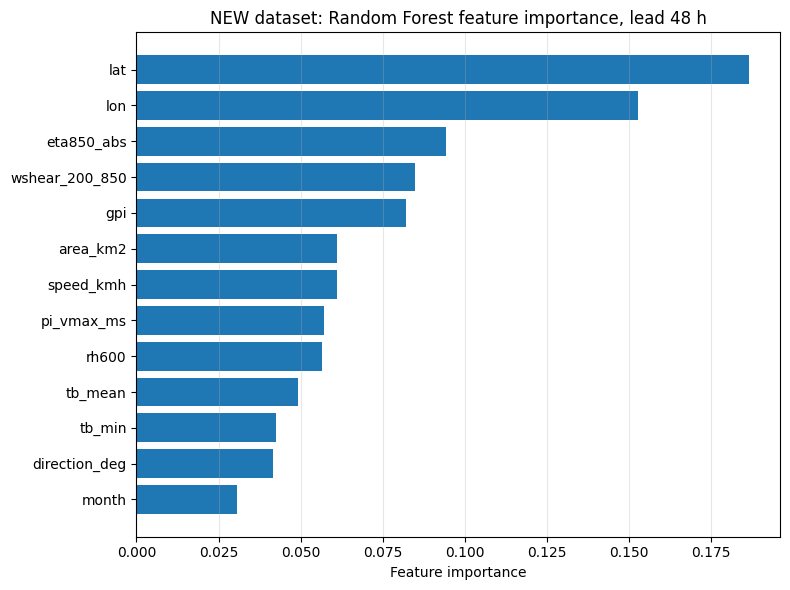

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_Random_Forest_48h.png
Feature importance: AdaBoost, lead 48h


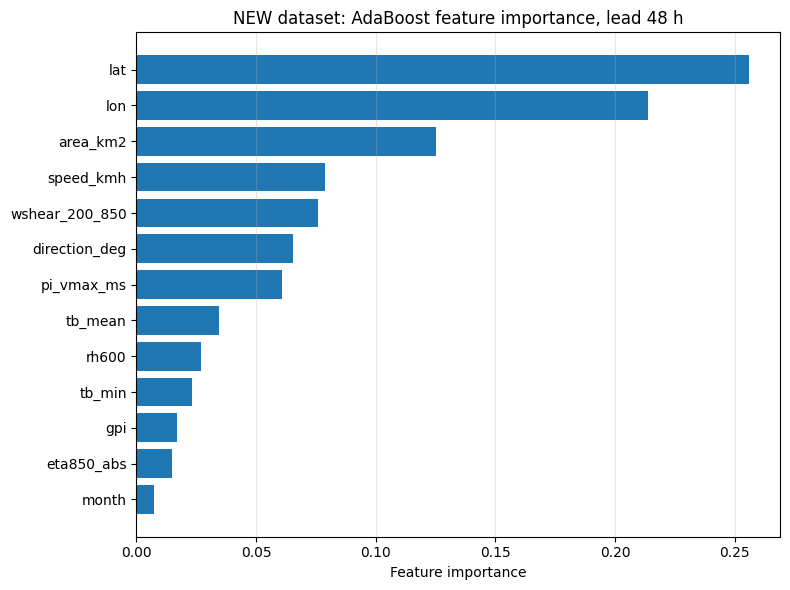

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_AdaBoost_48h.png
Feature importance: Decision Tree, lead 48h


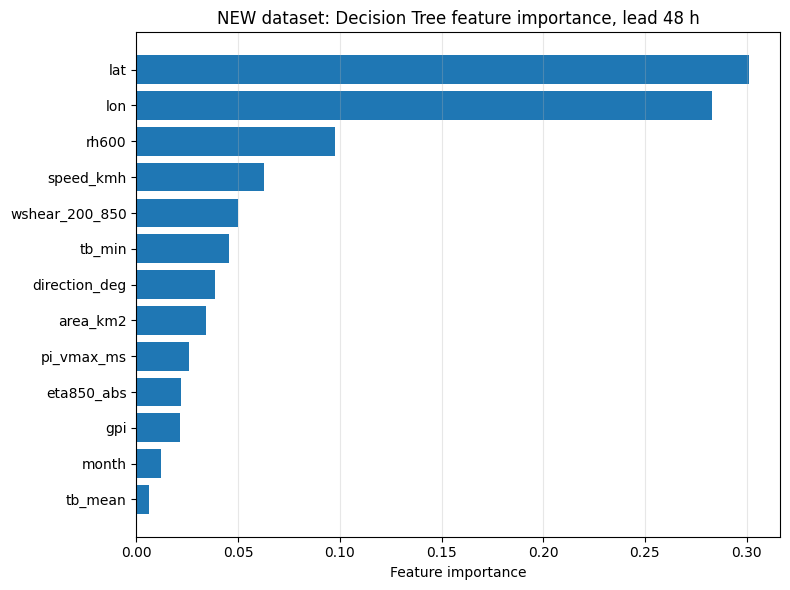

Saved: C:\Users\_s2218026\Documents\lab\mcs_output_softtest\ml_new_box2deg_2009_2025_UPDATED\feature_importance_new\feature_importance_new_Decision_Tree_48h.png


,lead_h,model,feature,importance
14,6,AdaBoost,lat,0.176687
13,6,AdaBoost,lon,0.157679
19,6,AdaBoost,speed_kmh,0.102257
24,6,AdaBoost,pi_vmax_ms,0.093294
16,6,AdaBoost,area_km2,0.087216
...,...,...,...,...
126,48,Random Forest,rh600,0.056380
121,48,Random Forest,tb_mean,0.049279
122,48,Random Forest,tb_min,0.042526
124,48,Random Forest,direction_deg,0.041592


In [55]:
# ============================================================
# FEATURE IMPORTANCE — NEW TREE MODELS
# Random Forest / AdaBoost / Decision Tree
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

tree_models = {
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=600,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]),

    "AdaBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", AdaBoostClassifier(
            n_estimators=600,
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]),
}

fi_rows = []

for lead in LEADS:
    df = datasets[lead].copy()

    X = df[FEATURE_COLS].copy()
    y = df["y"].astype(int).values

    for model_name, model in tree_models.items():
        print(f"Feature importance: {model_name}, lead {lead}h")

        model.fit(X, y)
        clf = model.named_steps["clf"]

        if not hasattr(clf, "feature_importances_"):
            print(f"[SKIP] {model_name} has no feature_importances_")
            continue

        imp = pd.DataFrame({
            "lead_h": lead,
            "model": model_name,
            "feature": FEATURE_COLS,
            "importance": clf.feature_importances_,
        })

        fi_rows.append(imp)

        imp_plot = imp.sort_values("importance", ascending=True)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(imp_plot["feature"], imp_plot["importance"])
        ax.set_xlabel("Feature importance")
        ax.set_title(f"NEW dataset: {model_name} feature importance, lead {lead} h")
        ax.grid(True, axis="x", alpha=0.3)

        plt.tight_layout()

        safe_model = model_name.replace(" ", "_").replace("/", "_")
        out_png = FI_DIR / f"feature_importance_new_{safe_model}_{lead}h.png"

        plt.savefig(out_png, dpi=220, bbox_inches="tight")
        plt.show()

        print("Saved:", out_png)

if fi_rows:
    fi_all = pd.concat(fi_rows, ignore_index=True)
    fi_all.to_csv(FI_DIR / "feature_importance_tree_models_new.csv", index=False)
    display(fi_all.sort_values(["lead_h", "model", "importance"], ascending=[True, True, False]))